# Figure 2: project progression and failure coefficients

This notebook estimates complementary log-log models for progression and failure from the **Concept**, **Feasibility**, and **FID/Construction** stages and visualises selected coefficients with 90% project-clustered confidence intervals.

The notebook separates data loading, model specification, estimation, diagnostics, coefficient extraction, and plotting. Region is included as a categorical model control but its treatment-coded coefficients are omitted from the coefficient charts. The main `figure_tornado.pdf` is a combined chart: the aggregate `any_enduse` coefficient comes from the corresponding alternate specification, while all other displayed coefficients come from the full grouped-end-use specification. Plot annotation positions and x-axis ranges are calculated separately for progression and failure.

Run Data Preparation first. This notebook reads `cloglog_data_processed.rds` and saves fitted model objects as `waterfall_results.rds`.

The country/macro specification uses the governance control selected in the master pipeline: `Governance_Score`, `Ease_of_doing_business`, or no additional governance control.


In [1]:
# Use the same project/data directory in standalone and master-run execution.
# With H2_PROJECT_DIR unset, run from the folder containing Data/ and the RDS files.
project_dir <- Sys.getenv("H2_PROJECT_DIR", unset = getwd())
project_dir <- normalizePath(project_dir, winslash = "/", mustWork = TRUE)
setwd(project_dir)

# The master pipeline passes this setting to each model notebook.
# Standalone execution defaults to Governance_Score.
governance_control <- Sys.getenv(
  "H2_GOVERNANCE_CONTROL",
  unset = "Governance_Score"
)

valid_governance_controls <- c(
  "Governance_Score",
  "Ease_of_doing_business",
  "none"
)

if (!governance_control %in% valid_governance_controls) {
  stop(
    paste0(
      "governance_control must be one of: ",
      paste(valid_governance_controls, collapse = ", ")
    )
  )
}


In [2]:
# ==============================================================================
# 1. PACKAGES AND ANALYSIS CONFIGURATION
# ==============================================================================

library(dplyr)
library(tidyr)
library(purrr)
library(tibble)
library(sandwich)
library(lmtest)
library(pROC)
library(ggplot2)
library(ggsci)
library(scales)
library(patchwork)
library(grid)

# ------------------------------------------------------------------------------
# File and estimation options
# ------------------------------------------------------------------------------

data_path <- "cloglog_data_processed.rds"


# Estimate every waterfall specification on the complete-case sample required by
# the most extensive specification.
use_common_sample <- TRUE

# Selected specifications used in the coefficient figures.
main_model_to_plot <- "Core + macro controls + year FE"
any_enduse_model_to_plot <- "Core + macro controls + year FE + any enduse"

# Confidence level used in Figure 2.
confidence_level <- 0.90

if (!file.exists(data_path)) {
  stop(
    paste0(
      "The input file '",
      data_path,
      "' was not found. Place it in the notebook working directory."
    )
  )
}



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard




## Load the model-ready data


In [3]:
# ==============================================================================
# 2. LOAD THE MODEL-READY DATA
# ==============================================================================

cloglog_data <- readRDS(
  data_path
)


# ------------------------------------------------------------------------------
# Validate the sequential Data Preparation -> Figure 2 handoff
# ------------------------------------------------------------------------------

required_prepared_columns <- c(
  "prev_left_truncated",
  "cap.mwel_log",
  "prev_time_in_status",
  "prev_time_in_status_raw",
  "Country_Risk_Spread_log",
  "region",
  "any_enduse"
)

missing_prepared_columns <- setdiff(
  required_prepared_columns,
  names(cloglog_data)
)

if (length(missing_prepared_columns) > 0) {
  stop(
    paste0(
      "The input data are not fully prepared for Figure 2. Missing columns: ",
      paste(
        missing_prepared_columns,
        collapse = ", "
      ),
      ". Run the Data Preparation notebook first."
    )
  )
}

if (
  any(
    cloglog_data$prev_left_truncated != 0,
    na.rm = TRUE
  )
) {
  stop(
    paste0(
      "The input data still contain transitions originating in left-truncated ",
      "status spells. Run the Data Preparation notebook first."
    )
  )
}


## Model controls and waterfall specifications

The first three specifications use separate grouped end-use indicators. The fourth replaces them with a single indicator for any recorded end-use. All later specifications are estimated on a common complete-case sample when `use_common_sample` is `TRUE`.


In [4]:
# ==============================================================================
# 3. DEFINE MODEL CONTROLS
# ==============================================================================


# ------------------------------------------------------------------------------
# End-use controls
# ------------------------------------------------------------------------------

enduse_controls_grouped <- c(
  "enduse_industrial",
  "enduse_transport",
  "enduse_chemicals",
  "enduse_power",
  "enduse_other"
)

enduse_controls_grouped <- enduse_controls_grouped[
  enduse_controls_grouped %in% names(cloglog_data)
]

if (length(enduse_controls_grouped) == 0) {
  stop("No grouped end-use variables were found in cloglog_data.")
}


# ------------------------------------------------------------------------------
# Confirm that Data Preparation created the aggregate end-use indicator
# ------------------------------------------------------------------------------

if (!"any_enduse" %in% names(cloglog_data)) {
  stop(
    paste0(
      "The any_enduse variable is missing. Run the Data Preparation ",
      "notebook before Figure 2."
    )
  )
}


# ------------------------------------------------------------------------------
# Core project-level controls
# ------------------------------------------------------------------------------

core_controls <- c(
  "cap.mwel_log",
  "prev_time_in_status",
  "technology",
#  "project_kde_50km",
  "electricity_source"
)


# ------------------------------------------------------------------------------
# Country- and region-level macro controls
# ------------------------------------------------------------------------------

governance_controls <- if (identical(governance_control, "none")) {
  character(0)
} else {
  governance_control
}

if (
  length(governance_controls) > 0L &&
  !governance_control %in% names(cloglog_data)
) {
  stop(
    paste0(
      "The selected governance control '",
      governance_control,
      "' is not available in cloglog_data_processed.rds."
    )
  )
}

macro_controls <- c(
  "Country_Risk_Spread_log",
  "RISE",
  "region",
  governance_controls
)


# ------------------------------------------------------------------------------
# Select controls present in the model data
# ------------------------------------------------------------------------------

core_controls <- core_controls[
  core_controls %in% names(cloglog_data)
]

macro_controls <- macro_controls[
  macro_controls %in% names(cloglog_data)
]


# ------------------------------------------------------------------------------
# Waterfall sequence
# ------------------------------------------------------------------------------

waterfall_control_steps <- list(
  "Core variables" = core_controls,

  "Core + macro controls" = c(
    core_controls,
    enduse_controls_grouped,
    macro_controls
  ),

  "Core + macro controls + year FE" = c(
    core_controls,
    enduse_controls_grouped,
    macro_controls,
    "factor(year)"
  ),

  "Core + macro controls + year FE + any enduse" = c(
    core_controls,
    macro_controls,
    "factor(year)",
    "any_enduse"
  )
)


## Estimation and clustered inference

Each transition is estimated with a complementary log-log generalized linear model. Standard errors are clustered by project reference. The diagnostic table records warnings, convergence failures, boundary probabilities, aliased coefficients, and invalid clustered variances by transition and specification.


In [5]:
# ==============================================================================
# 4. FORMULA, SAMPLE, AND INFERENCE HELPERS
# ==============================================================================


# ------------------------------------------------------------------------------
# Safely format variable names for model formulas
# ------------------------------------------------------------------------------

safe_term <- function(x) {
  if (x == "factor(year)") {
    return(x)
  }

  paste0(
    "`",
    x,
    "`"
  )
}


# ------------------------------------------------------------------------------
# Construct a complete-case model dataset
# ------------------------------------------------------------------------------

make_complete_model_data <- function(
    data,
    outcome,
    controls
) {
  raw_controls <- controls[
    controls != "factor(year)"
  ]

  raw_controls <- gsub(
    "`",
    "",
    raw_controls
  )

  # Keep the unstandardized duration alongside the model variables. It is
  # not included in the formula, but downstream prediction notebooks require it
  # to express cumulative curves in calendar years.
  auxiliary_vars <- c(
    "prev_time_in_status_raw"
  )

  model_vars <- unique(
    c(
      "reference",
      "year",
      outcome,
      raw_controls,
      auxiliary_vars
    )
  )

  model_vars <- model_vars[
    model_vars %in% names(data)
  ]

  data %>%
    dplyr::select(
      dplyr::all_of(model_vars)
    ) %>%
    tidyr::drop_na()
}


# ------------------------------------------------------------------------------
# Calculate project-clustered inference
# ------------------------------------------------------------------------------

calculate_clustered_inference <- function(
    model,
    model_data
) {
  inference_warnings <- character()
  inference_error <- NA_character_

  inference_result <- tryCatch(
    withCallingHandlers(
      {
        vcov_mat <- sandwich::vcovCL(
          model,
          cluster = model_data$reference
        )

        coefficient_test <- lmtest::coeftest(
          model,
          vcov. = vcov_mat
        )

        list(
          vcov_mat = vcov_mat,
          coefficient_test = coefficient_test
        )
      },
      warning = function(w) {
        inference_warnings <<- c(
          inference_warnings,
          conditionMessage(w)
        )

        invokeRestart("muffleWarning")
      }
    ),
    error = function(e) {
      inference_error <<- conditionMessage(e)
      NULL
    }
  )

  if (is.null(inference_result)) {
    return(
      list(
        vcov_mat = NULL,
        coefficient_test = NULL,
        inference_warnings = unique(inference_warnings),
        inference_error = inference_error,
        invalid_variance_terms = character(),
        invalid_inference_terms = character()
      )
    )
  }

  variance_diagonal <- diag(
    inference_result$vcov_mat
  )

  invalid_variance_terms <- names(variance_diagonal)[
    !is.finite(variance_diagonal) |
      variance_diagonal < 0
  ]

  coefficient_matrix <- as.matrix(
    inference_result$coefficient_test
  )

  invalid_inference_rows <- !is.finite(
    coefficient_matrix[, 2]
  ) |
    !is.finite(
      coefficient_matrix[, ncol(coefficient_matrix)]
    )

  invalid_inference_terms <- rownames(coefficient_matrix)[
    invalid_inference_rows
  ]

  list(
    vcov_mat = inference_result$vcov_mat,
    coefficient_test = inference_result$coefficient_test,
    inference_warnings = unique(inference_warnings),
    inference_error = inference_error,
    invalid_variance_terms = invalid_variance_terms,
    invalid_inference_terms = invalid_inference_terms
  )
}


In [6]:
# ==============================================================================
# 5. MODEL ESTIMATION AND RESULT EXTRACTION
# ==============================================================================


# ------------------------------------------------------------------------------
# Estimate one complementary log-log model
# ------------------------------------------------------------------------------

run_standard_cloglog <- function(
    data,
    outcome,
    controls
) {
  controls <- controls[
    controls == "factor(year)" |
      gsub("`", "", controls) %in% names(data)
  ]

  cleaned_controls <- gsub(
    "`",
    "",
    controls
  )

  include_year_fe <- "factor(year)" %in% controls

  model_data <- make_complete_model_data(
    data = data,
    outcome = outcome,
    controls = controls
  )

  if (nrow(model_data) == 0) {
    return(NULL)
  }

  if (!outcome %in% names(model_data)) {
    return(NULL)
  }

  if (dplyr::n_distinct(model_data[[outcome]]) < 2) {
    return(NULL)
  }

  if (
    "region" %in% cleaned_controls &&
      "region" %in% names(model_data)
  ) {
    model_data <- model_data %>%
      dplyr::mutate(
        region = factor(region)
      )
  }

  reference_year <- if (include_year_fe) {
    as.character(
      levels(
        factor(model_data$year)
      )[1]
    )
  } else {
    NA_character_
  }

  reference_region <- if (
    "region" %in% cleaned_controls &&
      "region" %in% names(model_data)
  ) {
    as.character(
      levels(model_data$region)[1]
    )
  } else {
    NA_character_
  }

  formula_terms <- vapply(
    controls,
    safe_term,
    character(1)
  )

  formula_rhs <- if (length(formula_terms) == 0) {
    "1"
  } else {
    paste(
      formula_terms,
      collapse = " + "
    )
  }

  model_formula <- stats::as.formula(
    paste(
      safe_term(outcome),
      "~",
      formula_rhs
    )
  )


  fit_warnings <- character()
  fit_error <- NA_character_

  model <- tryCatch(
    withCallingHandlers(
      stats::glm(
        formula = model_formula,
        data = model_data,
        family = stats::binomial(
          link = "cloglog"
        )
      ),
      warning = function(w) {
        fit_warnings <<- c(
          fit_warnings,
          conditionMessage(w)
        )

        invokeRestart("muffleWarning")
      }
    ),
    error = function(e) {
      fit_error <<- conditionMessage(e)
      NULL
    }
  )

  if (is.null(model)) {
    return(
      list(
        model = NULL,
        data = model_data,
        reference_year = reference_year,
        reference_region = reference_region,
        fit_warnings = unique(fit_warnings),
        fit_error = fit_error,
        converged = FALSE,
        boundary_probability_count = NA_integer_,
        aliased_coefficients = character(),
        extreme_coefficient_terms = character(),
        vcov_mat = NULL,
        coefficient_test = NULL,
        inference_warnings = character(),
        inference_error = NA_character_,
        invalid_variance_terms = character(),
        invalid_inference_terms = character()
      )
    )
  }

  fitted_probabilities <- stats::fitted(
    model
  )

  probability_tolerance <- 10 * .Machine$double.eps

  boundary_probability_count <- sum(
    !is.finite(fitted_probabilities) |
      fitted_probabilities <= probability_tolerance |
      fitted_probabilities >= 1 - probability_tolerance,
    na.rm = TRUE
  )

  coefficient_values <- stats::coef(
    model
  )

  aliased_coefficients <- names(coefficient_values)[
    is.na(coefficient_values)
  ]

  extreme_coefficient_terms <- names(coefficient_values)[
    is.finite(coefficient_values) &
      abs(coefficient_values) > 50
  ]

  clustered_inference <- calculate_clustered_inference(
    model = model,
    model_data = model_data
  )

  list(
    model = model,
    data = model_data,
    reference_year = reference_year,
    reference_region = reference_region,
    fit_warnings = unique(fit_warnings),
    fit_error = fit_error,
    converged = isTRUE(model$converged),
    boundary_probability_count = boundary_probability_count,
    aliased_coefficients = aliased_coefficients,
    extreme_coefficient_terms = extreme_coefficient_terms,
    vcov_mat = clustered_inference$vcov_mat,
    coefficient_test = clustered_inference$coefficient_test,
    inference_warnings = clustered_inference$inference_warnings,
    inference_error = clustered_inference$inference_error,
    invalid_variance_terms = clustered_inference$invalid_variance_terms,
    invalid_inference_terms = clustered_inference$invalid_inference_terms
  )
}


# ------------------------------------------------------------------------------
# Extract coefficients for the waterfall tables
# ------------------------------------------------------------------------------

extract_standard_cloglog <- function(
    model_obj,
    model_name
) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.null(model_obj$coefficient_test)
  ) {
    output <- data.frame(
      variable = character(),
      stringsAsFactors = FALSE
    )

    output[[model_name]] <- character()

    return(output)
  }

  coefficient_matrix <- as.matrix(
    model_obj$coefficient_test
  )

  output <- data.frame(
    variable = rownames(coefficient_matrix),
    estimate = as.numeric(
      coefficient_matrix[, 1]
    ),
    p.value = as.numeric(
      coefficient_matrix[, ncol(coefficient_matrix)]
    ),
    stringsAsFactors = FALSE
  ) %>%
    dplyr::filter(
      variable != "(Intercept)"
    ) %>%
    dplyr::filter(
      !grepl(
        "^factor\\(year\\)",
        variable
      )
    ) %>%
    dplyr::mutate(
      significance = dplyr::case_when(
        !is.na(p.value) & p.value < 0.001 ~ "***",
        !is.na(p.value) & p.value < 0.01 ~ "**",
        !is.na(p.value) & p.value < 0.05 ~ "*",
        !is.na(p.value) & p.value < 0.10 ~ "+",
        TRUE ~ ""
      ),
      coefficient = paste0(
        sprintf(
          "%.4f",
          estimate
        ),
        significance
      )
    ) %>%
    dplyr::select(
      variable,
      coefficient
    )

  names(output)[
    names(output) == "coefficient"
  ] <- model_name

  output
}


In [7]:
# ==============================================================================
# 6. MODEL PERFORMANCE AND WATERFALL HELPERS
# ==============================================================================

calc_auc <- function(
    model_obj,
    outcome
) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  predicted_probability <- stats::predict(
    model_obj$model,
    newdata = model_obj$data,
    type = "response"
  )

  actual_outcome <- model_obj$data[[outcome]]

  valid_rows <- !is.na(predicted_probability) &
    !is.na(actual_outcome)

  if (
    sum(valid_rows) == 0 ||
      dplyr::n_distinct(actual_outcome[valid_rows]) < 2
  ) {
    return(NA_real_)
  }

  roc_object <- pROC::roc(
    actual_outcome[valid_rows],
    predicted_probability[valid_rows],
    quiet = TRUE
  )

  as.numeric(
    pROC::auc(
      roc_object
    )
  )
}

calc_pseudo_r2 <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  outcome <- all.vars(
    stats::formula(
      model_obj$model
    )
  )[1]

  null_formula <- stats::as.formula(
    paste(
      safe_term(outcome),
      "~ 1"
    )
  )

  null_model <- suppressWarnings(
    stats::glm(
      formula = null_formula,
      data = model_obj$data,
      family = stats::binomial(
        link = "cloglog"
      )
    )
  )

  1 -
    stats::deviance(model_obj$model) /
    stats::deviance(null_model)
}

get_n <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  nrow(model_obj$data)
}

get_years <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  dplyr::n_distinct(
    model_obj$data$year
  )
}

get_events <- function(
    model_obj,
    outcome
) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  sum(
    model_obj$data[[outcome]] == 1,
    na.rm = TRUE
  )
}

get_aic <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  stats::AIC(
    model_obj$model
  )
}

get_bic <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  stats::BIC(
    model_obj$model
  )
}

get_reference_year <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.na(model_obj$reference_year)
  ) {
    return("")
  }

  model_obj$reference_year
}

get_reference_region <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.na(model_obj$reference_region)
  ) {
    return("")
  }

  model_obj$reference_region
}

format_numeric_stat <- function(
    x,
    digits = 3
) {
  ifelse(
    is.na(x),
    "",
    sprintf(
      paste0(
        "%.",
        digits,
        "f"
      ),
      x
    )
  )
}

classify_variable_block <- function(
    variable,
    core_controls,
    macro_controls
) {
  cleaned_core_controls <- gsub(
    "`",
    "",
    core_controls
  )

  cleaned_macro_controls <- gsub(
    "`",
    "",
    macro_controls
  )

  is_core <- vapply(
    cleaned_core_controls,
    function(control) {
      startsWith(
        variable,
        control
      )
    },
    logical(1)
  )

  is_macro <- vapply(
    cleaned_macro_controls,
    function(control) {
      startsWith(
        variable,
        control
      )
    },
    logical(1)
  )

  dplyr::case_when(
    any(is_core) ~ "Core variables",
    any(is_macro) ~ "Macro controls",
    TRUE ~ "Other"
  )
}


In [8]:
# ==============================================================================
# 7. TRANSITION-SPECIFIC AND FULL WATERFALL ESTIMATION
# ==============================================================================

run_transition_waterfall <- function(
    data,
    transition_name,
    outcome,
    control_steps,
    core_controls,
    macro_controls,
    use_common_sample = TRUE
) {
  max_controls <- unique(
    unlist(
      control_steps,
      use.names = FALSE
    )
  )

  if (use_common_sample) {
    data_for_models <- make_complete_model_data(
      data = data,
      outcome = outcome,
      controls = max_controls
    )
  } else {
    data_for_models <- data
  }

  models <- lapply(
    control_steps,
    function(step_controls) {
      run_standard_cloglog(
        data = data_for_models,
        outcome = outcome,
        controls = step_controls
      )
    }
  )

  coefficient_tables <- Map(
    extract_standard_cloglog,
    model_obj = models,
    model_name = names(models)
  )

  coefficient_table <- Reduce(
    function(x, y) {
      dplyr::full_join(
        x,
        y,
        by = "variable"
      )
    },
    coefficient_tables
  ) %>%
    dplyr::mutate(
      dplyr::across(
        -variable,
        ~ tidyr::replace_na(
          .x,
          ""
        )
      ),
      transition = transition_name,
      variable_block = vapply(
        variable,
        classify_variable_block,
        character(1),
        core_controls = core_controls,
        macro_controls = macro_controls
      )
    ) %>%
    dplyr::select(
      transition,
      variable_block,
      variable,
      dplyr::everything()
    ) %>%
    dplyr::arrange(
      factor(
        variable_block,
        levels = c(
          "Core variables",
          "Macro controls",
          "Other"
        )
      ),
      variable
    )

  stat_row <- function(
      label,
      values
  ) {
    output <- data.frame(
      transition = transition_name,
      statistic = label,
      t(
        as.character(values)
      ),
      check.names = FALSE
    )

    names(output)[-(1:2)] <- names(models)

    output
  }

  cleaned_macro_controls <- gsub(
    "`",
    "",
    macro_controls
  )

  macro_control_indicator <- vapply(
    control_steps,
    function(step_controls) {
      cleaned_step_controls <- gsub(
        "`",
        "",
        step_controls
      )

      all(
        cleaned_macro_controls %in% cleaned_step_controls
      )
    },
    logical(1)
  )

  region_control_indicator <- vapply(
    control_steps,
    function(step_controls) {
      "region" %in% gsub(
        "`",
        "",
        step_controls
      )
    },
    logical(1)
  )

  year_fe_indicator <- vapply(
    control_steps,
    function(step_controls) {
      "factor(year)" %in% step_controls
    },
    logical(1)
  )

  statistics_table <- dplyr::bind_rows(
    stat_row(
      "Macro controls",
      ifelse(
        macro_control_indicator,
        "Yes",
        "No"
      )
    ),
    stat_row(
      "Region control",
      ifelse(
        region_control_indicator,
        "Yes",
        "No"
      )
    ),
    stat_row(
      "Reference region",
      vapply(
        models,
        get_reference_region,
        character(1)
      )
    ),
    stat_row(
      "Year fixed effects",
      ifelse(
        year_fe_indicator,
        "Yes",
        "No"
      )
    ),
    stat_row(
      "Reference year",
      vapply(
        models,
        get_reference_year,
        character(1)
      )
    ),
    stat_row(
      "Common sample",
      rep(
        ifelse(
          use_common_sample,
          "Yes",
          "No"
        ),
        length(models)
      )
    ),
    stat_row(
      "N observations",
      vapply(
        models,
        get_n,
        numeric(1)
      )
    ),
    stat_row(
      "N years",
      vapply(
        models,
        get_years,
        numeric(1)
      )
    ),
    stat_row(
      "N transitions",
      vapply(
        models,
        get_events,
        numeric(1),
        outcome = outcome
      )
    ),
    stat_row(
      "AIC",
      format_numeric_stat(
        vapply(
          models,
          get_aic,
          numeric(1)
        ),
        digits = 2
      )
    ),
    stat_row(
      "BIC",
      format_numeric_stat(
        vapply(
          models,
          get_bic,
          numeric(1)
        ),
        digits = 2
      )
    ),
    stat_row(
      "Pseudo R2",
      format_numeric_stat(
        vapply(
          models,
          calc_pseudo_r2,
          numeric(1)
        ),
        digits = 3
      )
    ),
    stat_row(
      "AUC",
      format_numeric_stat(
        vapply(
          models,
          calc_auc,
          numeric(1),
          outcome = outcome
        ),
        digits = 3
      )
    )
  )

  list(
    coef_table = coefficient_table,
    stats_table = statistics_table,
    models = models
  )
}

run_cloglog_waterfall <- function(
    data,
    control_steps,
    core_controls,
    macro_controls,
    use_common_sample = TRUE
) {
  model_specs <- list(
    "Concept -> Progress" = list(
      data = dplyr::filter(
        data,
        prev_state == 1
      ),
      outcome = "progress"
    ),

    "Concept -> Failure" = list(
      data = dplyr::filter(
        data,
        prev_state == 1
      ),
      outcome = "failure"
    ),

    "Feasibility -> Progress" = list(
      data = dplyr::filter(
        data,
        prev_state == 2
      ),
      outcome = "progress"
    ),

    "Feasibility -> Failure" = list(
      data = dplyr::filter(
        data,
        prev_state == 2
      ),
      outcome = "failure"
    ),

    "FID -> Progress" = list(
      data = dplyr::filter(
        data,
        prev_state == 3
      ),
      outcome = "progress"
    ),

    "FID -> Failure" = list(
      data = dplyr::filter(
        data,
        prev_state == 3
      ),
      outcome = "failure"
    )
  )

  results <- Map(
    function(spec, transition_name) {
      run_transition_waterfall(
        data = spec$data,
        transition_name = transition_name,
        outcome = spec$outcome,
        control_steps = control_steps,
        core_controls = core_controls,
        macro_controls = macro_controls,
        use_common_sample = use_common_sample
      )
    },
    spec = model_specs,
    transition_name = names(model_specs)
  )

  coefficient_tables <- lapply(
    results,
    function(result) {
      result$coef_table
    }
  )

  statistics_tables <- lapply(
    results,
    function(result) {
      result$stats_table
    }
  )

  fitted_models <- lapply(
    results,
    function(result) {
      result$models
    }
  )

  list(
    coef_table = dplyr::bind_rows(
      coefficient_tables
    ),
    stats_table = dplyr::bind_rows(
      statistics_tables
    ),
    models = fitted_models
  )
}


In [9]:
# ==============================================================================
# 8. MODEL DIAGNOSTICS
# ==============================================================================

build_model_diagnostics <- function(waterfall_results) {
  purrr::imap_dfr(
    waterfall_results$models,
    function(transition_models, transition_name) {
      purrr::imap_dfr(
        transition_models,
        function(model_obj, model_name) {
          diagnostic_rows <- list()

          add_issue <- function(issue, details) {
            diagnostic_rows <<- append(
              diagnostic_rows,
              list(
                tibble::tibble(
                  transition = transition_name,
                  model = model_name,
                  issue = issue,
                  details = details
                )
              )
            )
          }

          if (is.null(model_obj)) {
            add_issue(
              "Model not estimated",
              "No estimable model object was returned."
            )

            return(
              dplyr::bind_rows(diagnostic_rows)
            )
          }

          if (
            !is.null(model_obj$fit_error) &&
              !is.na(model_obj$fit_error)
          ) {
            add_issue(
              "Model fitting error",
              model_obj$fit_error
            )
          }

          if (length(model_obj$fit_warnings) > 0) {
            add_issue(
              "Model fitting warning",
              paste(
                unique(model_obj$fit_warnings),
                collapse = " | "
              )
            )
          }

          if (!isTRUE(model_obj$converged)) {
            add_issue(
              "Model did not converge",
              "glm$converged is FALSE."
            )
          }

          if (
            !is.na(model_obj$boundary_probability_count) &&
              model_obj$boundary_probability_count > 0
          ) {
            add_issue(
              "Boundary fitted probabilities",
              paste0(
                model_obj$boundary_probability_count,
                " fitted probabilities were numerically zero, one, or non-finite."
              )
            )
          }

          if (length(model_obj$extreme_coefficient_terms) > 0) {
            add_issue(
              "Extreme coefficient magnitude",
              paste0(
                "Absolute coefficient above 50: ",
                paste(
                  model_obj$extreme_coefficient_terms,
                  collapse = ", "
                )
              )
            )
          }

          if (length(model_obj$aliased_coefficients) > 0) {
            add_issue(
              "Aliased coefficients",
              paste(
                model_obj$aliased_coefficients,
                collapse = ", "
              )
            )
          }

          if (length(model_obj$inference_warnings) > 0) {
            add_issue(
              "Clustered inference warning",
              paste(
                unique(model_obj$inference_warnings),
                collapse = " | "
              )
            )
          }

          if (
            !is.null(model_obj$inference_error) &&
              !is.na(model_obj$inference_error)
          ) {
            add_issue(
              "Clustered inference error",
              model_obj$inference_error
            )
          }

          if (length(model_obj$invalid_variance_terms) > 0) {
            add_issue(
              "Invalid clustered variance",
              paste(
                model_obj$invalid_variance_terms,
                collapse = ", "
              )
            )
          }

          if (length(model_obj$invalid_inference_terms) > 0) {
            add_issue(
              "Non-finite clustered inference",
              paste(
                model_obj$invalid_inference_terms,
                collapse = ", "
              )
            )
          }

          dplyr::bind_rows(
            diagnostic_rows
          )
        }
      )
    }
  )
}


## Estimate and save the models

The following cells run the six transition models, save the full result object, and create a compact comparison table for the two Figure 2 specifications.


In [10]:
# ==============================================================================
# 9. RUN AND SAVE THE MODELS
# ==============================================================================

waterfall_results <- run_cloglog_waterfall(
  data = cloglog_data,
  control_steps = waterfall_control_steps,
  core_controls = core_controls,
  macro_controls = macro_controls,
  use_common_sample = use_common_sample
)

waterfall_results$governance_control <- governance_control

waterfall_coef_table <- waterfall_results$coef_table
waterfall_stats_table <- waterfall_results$stats_table

model_diagnostics <- build_model_diagnostics(
  waterfall_results
)


waterfall_results$diagnostics <- model_diagnostics

options(
  width = 1000
)

print(
  waterfall_coef_table,
  row.names = FALSE
)

print(
  waterfall_stats_table,
  row.names = FALSE
)

saveRDS(
  waterfall_results,
  "waterfall_results.rds"
)


              transition variable_block                              variable Core variables Core + macro controls Core + macro controls + year FE Core + macro controls + year FE + any enduse
     Concept -> Progress Core variables                          cap.mwel_log      -0.2795**             -0.3170**                       -0.3202**                                    -0.2664**
     Concept -> Progress Core variables electricity_sourceDedicated Renewable        -0.0502                0.0965                         -0.0169                                       0.0323
     Concept -> Progress Core variables                   prev_time_in_status     -0.4643***            -0.4669***                        -0.2303+                                     -0.2411+
     Concept -> Progress Core variables                       technologyOther     -1.1487***            -1.1416***                      -1.0562***                                   -1.0371***
     Concept -> Progress Core variables 

In [11]:
# ==============================================================================
# 10. SAMPLE SIZES AND GOODNESS-OF-FIT STATISTICS
# ==============================================================================

models_to_summarize <- c(
  "Core + macro controls + year FE",
  "Core + macro controls + year FE + any enduse"
)

model_labels <- c(
  "Core + macro controls + year FE" = "Specific end-use model",
  "Core + macro controls + year FE + any enduse" = "Any-end-use model"
)

transition_outcomes <- c(
  "Concept -> Progress" = "progress",
  "Concept -> Failure" = "failure",
  "Feasibility -> Progress" = "progress",
  "Feasibility -> Failure" = "failure",
  "FID -> Progress" = "progress",
  "FID -> Failure" = "failure"
)

model_summary_table <- purrr::imap_dfr(
  waterfall_results$models,
  function(transition_models, transition_name) {
    outcome <- transition_outcomes[[transition_name]]

    purrr::map_dfr(
      models_to_summarize,
      function(model_name) {
        model_obj <- transition_models[[model_name]]

        if (
          is.null(model_obj) ||
            is.null(model_obj$model)
        ) {
          return(
            tibble::tibble(
              transition = transition_name,
              model = model_labels[[model_name]],
              unique_projects = NA_integer_,
              unique_project_years = NA_integer_,
              observed_transitions = NA_integer_,
              AIC = NA_real_,
              BIC = NA_real_,
              pseudo_R2 = NA_real_,
              AUC = NA_real_
            )
          )
        }

        model_data <- model_obj$data

        tibble::tibble(
          transition = transition_name,
          model = model_labels[[model_name]],
          unique_projects = dplyr::n_distinct(
            model_data$reference
          ),
          unique_project_years = model_data %>%
            dplyr::distinct(
              reference,
              year
            ) %>%
            nrow(),
          observed_transitions = sum(
            model_data[[outcome]] == 1,
            na.rm = TRUE
          ),
          AIC = stats::AIC(
            model_obj$model
          ),
          BIC = stats::BIC(
            model_obj$model
          ),
          pseudo_R2 = calc_pseudo_r2(
            model_obj
          ),
          AUC = calc_auc(
            model_obj,
            outcome
          )
        )
      }
    )
  }
) %>%
  dplyr::mutate(
    transition = factor(
      transition,
      levels = names(transition_outcomes)
    ),
    model = factor(
      model,
      levels = unname(
        model_labels[models_to_summarize]
      )
    ),
    AIC = round(AIC, 2),
    BIC = round(BIC, 2),
    pseudo_R2 = round(pseudo_R2, 3),
    AUC = round(AUC, 3)
  ) %>%
  dplyr::arrange(
    transition,
    model
  ) %>%
  dplyr::rename(
    "Transition" = transition,
    "Model specification" = model,
    "Unique projects" = unique_projects,
    "Unique project-years" = unique_project_years,
    "Observed transitions" = observed_transitions,
    "Pseudo R2" = pseudo_R2,
    "In-sample AUC" = AUC
  )

print(
  model_summary_table,
  n = Inf,
  width = Inf
)

utils::write.csv(
  model_summary_table,
  "model_summary_table.csv",
  row.names = FALSE
)


# A tibble: 12 × 9
   Transition              `Model specification`  `Unique projects` `Unique project-years` `Observed transitions`   AIC   BIC `Pseudo R2` `In-sample AUC`
   <fct>                   <fct>                              <int>                  <int>                  <int> <dbl> <dbl>       <dbl>           <dbl>
 1 Concept -> Progress     Specific end-use model               761                   1724                    116  803.  917.       0.105           0.737
 2 Concept -> Progress     Any-end-use model                    761                   1724                    116  795.  888.       0.105           0.741
 3 Concept -> Failure      Specific end-use model               761                   1724                    103  701.  815.       0.156           0.8  
 4 Concept -> Failure      Any-end-use model                    761                   1724                    103  698.  791.       0.149           0.796
 5 Feasibility -> Progress Specific end-use model        

## Human-readable effect sizes

The model covariates for capacity and country risk are signed-`log1p` transformed and then standardized in Data Preparation. The calculations below translate the fitted coefficients back into changes that are easier to interpret in the manuscript. For capacity, the table reports the effect of doubling capacity from the median capacity in each model sample. For country risk, it reports both the 25th-to-75th percentile contrast and, as a backup, a doubling from the median country-risk value. Capacity and country-risk coefficients are taken from the grouped end-use specification, matching the source of those non-end-use coefficients in the hybrid `figure_tornado.pdf`; only the aggregate Any end-use coefficient in that figure comes from the any-end-use specification. Because `log1p(x)` is not exactly `log(x)`, a doubling has a slightly baseline-dependent effect; the raw baseline and comparison values are therefore printed explicitly.


In [12]:
# ==============================================================================
# 10B. BACK-TRANSFORMED EFFECT SIZES FOR MANUSCRIPT INTERPRETATION
# ==============================================================================
#
# Capacity and country risk were signed-log1p transformed and then standardized
# in Data Preparation. The coefficient therefore applies to a one-unit change
# in the standardized transformed variable. This section converts substantively
# meaningful changes in the original variables into that model scale.
#
# Outputs:
#   1) Capacity: median -> 2 x median
#   2) Country risk: 25th -> 75th percentile
#   3) Country risk: median -> 2 x median (backup)
#
# The calculations use the same project-year sample as the full grouped-end-use
# model for each transition and the original standardization SD stored by Data Preparation.


# ------------------------------------------------------------------------------
# Recover preprocessing information
# ------------------------------------------------------------------------------

standardize_numeric_setting <- attr(
  cloglog_data,
  "standardize_numeric"
)

if (is.null(standardize_numeric_setting)) {
  stop(
    paste0(
      "The model-ready RDS does not record whether numeric variables were ",
      "standardized. Re-run Data Preparation before calculating effect sizes."
    )
  )
}

standardize_numeric_used <- isTRUE(
  standardize_numeric_setting
)

standardization_parameters <- attr(
  cloglog_data,
  "standardization_parameters"
)

if (
  standardize_numeric_used &&
    (
      is.null(standardization_parameters) ||
        !all(
          c(
            "variable",
            "mean",
            "sd"
          ) %in% names(standardization_parameters)
        )
    )
) {
  stop(
    paste0(
      "The model-ready RDS does not contain the standardization parameters ",
      "needed to back-transform effect sizes. Re-run Data Preparation first."
    )
  )
}


# ------------------------------------------------------------------------------
# Transformation helpers
# ------------------------------------------------------------------------------

signed_log1p <- function(x) {
  sign(x) * log1p(abs(x))
}

get_preprocessing_sd <- function(variable_name) {
  if (!standardize_numeric_used) {
    return(1)
  }

  variable_sd <- standardization_parameters %>%
    dplyr::filter(
      variable == variable_name
    ) %>%
    dplyr::pull(
      sd
    )

  if (
    length(variable_sd) != 1 ||
      !is.finite(variable_sd) ||
      variable_sd <= 0
  ) {
    stop(
      paste0(
        "No valid preprocessing SD found for ",
        variable_name,
        "."
      )
    )
  }

  variable_sd
}

get_clustered_coefficient <- function(
    model_obj,
    variable_name
) {
  coefficient_matrix <- as.matrix(
    model_obj$coefficient_test
  )

  coefficient_names <- gsub(
    "`",
    "",
    rownames(coefficient_matrix)
  )

  coefficient_row <- which(
    coefficient_names == variable_name
  )

  if (length(coefficient_row) != 1) {
    stop(
      paste0(
        "Could not uniquely identify coefficient ",
        variable_name,
        "."
      )
    )
  }

  tibble::tibble(
    beta = as.numeric(
      coefficient_matrix[coefficient_row, 1]
    ),
    standard_error = as.numeric(
      coefficient_matrix[coefficient_row, 2]
    ),
    p_value = as.numeric(
      coefficient_matrix[
        coefficient_row,
        ncol(coefficient_matrix)
      ]
    )
  )
}

get_raw_model_sample <- function(
    model_obj,
    raw_variable
) {
  if (!raw_variable %in% names(cloglog_data)) {
    stop(
      paste0(
        "Raw variable ",
        raw_variable,
        " is not present in cloglog_data."
      )
    )
  }

  model_keys <- model_obj$data %>%
    dplyr::select(
      reference,
      year
    ) %>%
    dplyr::distinct()

  raw_sample <- model_keys %>%
    dplyr::left_join(
      cloglog_data %>%
        dplyr::select(
          reference,
          year,
          dplyr::all_of(raw_variable)
        ),
      by = c(
        "reference",
        "year"
      )
    )

  raw_sample[[raw_variable]] <- suppressWarnings(
    as.numeric(
      raw_sample[[raw_variable]]
    )
  )

  raw_sample
}

calculate_contrast_effect <- function(
    model_obj,
    model_variable,
    raw_variable,
    baseline,
    comparison,
    contrast_label
) {
  coefficient_info <- get_clustered_coefficient(
    model_obj = model_obj,
    variable_name = model_variable
  )

  preprocessing_sd <- get_preprocessing_sd(
    model_variable
  )

  transformed_baseline <- signed_log1p(
    baseline
  )

  transformed_comparison <- signed_log1p(
    comparison
  )

  model_scale_change <- (
    transformed_comparison -
      transformed_baseline
  ) / preprocessing_sd

  log_hazard_ratio <- coefficient_info$beta *
    model_scale_change

  hazard_ratio <- exp(
    log_hazard_ratio
  )

  tibble::tibble(
    variable = raw_variable,
    contrast = contrast_label,
    baseline = baseline,
    comparison = comparison,
    model_scale_change = model_scale_change,
    beta = coefficient_info$beta,
    p_value = coefficient_info$p_value,
    hazard_ratio = hazard_ratio,
    percent_change = 100 * (
      hazard_ratio - 1
    )
  )
}


# ------------------------------------------------------------------------------
# Calculate requested contrasts for each transition
# ------------------------------------------------------------------------------

interpretation_transition_names <- names(
  waterfall_results$models
)

if (length(interpretation_transition_names) == 0) {
  stop(
    "No fitted transition models were found in waterfall_results."
  )
}

effect_size_model_to_use <- main_model_to_plot

interpretation_effects <- purrr::map_dfr(
  interpretation_transition_names,
  function(transition_name) {
    model_obj <- waterfall_results$models[[transition_name]][[effect_size_model_to_use]]

    if (
      is.null(model_obj) ||
        is.null(model_obj$model) ||
        is.null(model_obj$coefficient_test)
    ) {
      return(
        tibble::tibble()
      )
    }

    capacity_sample <- get_raw_model_sample(
      model_obj = model_obj,
      raw_variable = "cap.mwel"
    )

    capacity_values <- capacity_sample$cap.mwel[
      is.finite(
        capacity_sample$cap.mwel
      ) &
        capacity_sample$cap.mwel >= 0
    ]

    if (length(capacity_values) == 0) {
      stop(
        paste0(
          "No valid non-negative capacity observations for ",
          transition_name,
          "."
        )
      )
    }

    capacity_median <- stats::median(
      capacity_values,
      na.rm = TRUE
    )

    capacity_doubling <- calculate_contrast_effect(
      model_obj = model_obj,
      model_variable = "cap.mwel_log",
      raw_variable = "cap.mwel",
      baseline = capacity_median,
      comparison = 2 * capacity_median,
      contrast_label = "Median -> 2 x median"
    )

    risk_sample <- get_raw_model_sample(
      model_obj = model_obj,
      raw_variable = "Country_Risk_Spread"
    )

    risk_values <- risk_sample$Country_Risk_Spread[
      is.finite(
        risk_sample$Country_Risk_Spread
      )
    ]

    if (length(risk_values) == 0) {
      stop(
        paste0(
          "No valid country-risk observations for ",
          transition_name,
          "."
        )
      )
    }

    risk_quantiles <- stats::quantile(
      risk_values,
      probs = c(
        0.25,
        0.75
      ),
      na.rm = TRUE,
      names = FALSE,
      type = 7
    )

    risk_iqr <- calculate_contrast_effect(
      model_obj = model_obj,
      model_variable = "Country_Risk_Spread_log",
      raw_variable = "Country_Risk_Spread",
      baseline = risk_quantiles[1],
      comparison = risk_quantiles[2],
      contrast_label = "25th -> 75th percentile"
    )

    risk_median <- stats::median(
      risk_values,
      na.rm = TRUE
    )

    risk_doubling <- calculate_contrast_effect(
      model_obj = model_obj,
      model_variable = "Country_Risk_Spread_log",
      raw_variable = "Country_Risk_Spread",
      baseline = risk_median,
      comparison = 2 * risk_median,
      contrast_label = "Median -> 2 x median"
    )

    dplyr::bind_rows(
      capacity_doubling,
      risk_iqr,
      risk_doubling
    ) %>%
      dplyr::mutate(
        transition = transition_name,
        .before = 1
      )
  }
)


# ------------------------------------------------------------------------------
# Add readable labels and print/export the table
# ------------------------------------------------------------------------------

interpretation_effects <- interpretation_effects %>%
  dplyr::mutate(
    variable_label = dplyr::recode(
      variable,
      "cap.mwel" = "Project capacity (MWel)",
      "Country_Risk_Spread" = "Country risk"
    ),
    direction = dplyr::case_when(
      percent_change > 0 ~ "higher",
      percent_change < 0 ~ "lower",
      TRUE ~ "no change"
    ),
    percent_change_absolute = abs(
      percent_change
    ),
    manuscript_effect = dplyr::case_when(
      percent_change > 0 ~ paste0(
        round(
          percent_change_absolute,
          1
        ),
        "% higher"
      ),
      percent_change < 0 ~ paste0(
        round(
          percent_change_absolute,
          1
        ),
        "% lower"
      ),
      TRUE ~ "no change"
    )
  ) %>%
  dplyr::select(
    transition,
    variable_label,
    contrast,
    baseline,
    comparison,
    beta,
    p_value,
    model_scale_change,
    hazard_ratio,
    percent_change,
    manuscript_effect
  )

cat(
  "\nHuman-readable effect sizes matching the combined tornado figure\n"
)

print(
  interpretation_effects,
  n = Inf,
  width = Inf
)

utils::write.csv(
  interpretation_effects,
  "human_readable_effect_sizes.csv",
  row.names = FALSE
)



Human-readable effect sizes matching the combined tornado figure
# A tibble: 18 × 11
   transition              variable_label          contrast                 baseline comparison    beta      p_value model_scale_change hazard_ratio percent_change manuscript_effect
   <chr>                   <chr>                   <chr>                       <dbl>      <dbl>   <dbl>        <dbl>              <dbl>        <dbl>          <dbl> <chr>            
 1 Concept -> Progress     Project capacity (MWel) Median -> 2 x median    225         450      -0.320  0.00127                   0.288        0.912         -8.80  8.8% lower       
 2 Concept -> Progress     Country risk            25th -> 75th percentile   0.00233     0.0285 -0.293  0.0469                    1.16         0.712        -28.8   28.8% lower      
 3 Concept -> Progress     Country risk            Median -> 2 x median      0.0100      0.0201 -0.293  0.0469                    0.446        0.877        -12.3   12.3% lower      
 4 C

## Figure construction

The main figure displays coefficient estimates from the `any_enduse` specification as horizontal 90% confidence-interval bars. The progress and failure columns use separate data-driven x-axis ranges. The separate full/reference figure additionally shows the specific end-use indicators.


In [13]:
# ==============================================================================
# 11. PLOT CONFIGURATION, LABELS, AND THEME
# ==============================================================================


# ------------------------------------------------------------------------------
# Define project stages and corresponding transitions
# ------------------------------------------------------------------------------

stage_pairs <- tibble::tibble(
  stage = c(
    "Concept",
    "Feasibility",
    "FID"
  ),
  progress_transition = c(
    "Concept -> Progress",
    "Feasibility -> Progress",
    "FID -> Progress"
  ),
  failure_transition = c(
    "Concept -> Failure",
    "Feasibility -> Failure",
    "FID -> Failure"
  )
)

transition_names <- c(
  stage_pairs$progress_transition,
  stage_pairs$failure_transition
)


# ------------------------------------------------------------------------------
# Human-readable variable labels
# ------------------------------------------------------------------------------

term_labels <- c(
  cap.mwel_log = "Capacity, MWel log",
  prev_time_in_status = "Time in stage",
  technology = "Technology",
  instability = "Capacity revision",
  project_kde_50km = "Project density, 50 km",
  electricity_source = "Electricity source",
  any_enduse = "Any end-use",
  enduse_industrial = "Industrial end-use",
  enduse_chemicals = "Chemicals end-use",
  enduse.ammonia = "Ammonia end-use",
  enduse.methanol = "Methanol end-use",
  enduse_transport = "Transport end-use",
  enduse_power = "Power end-use",
  enduse_other = "Other end-use",
  Anhydrous_Ammonia_Export_log = "Ammonia exports log",
  Competitive_Industrial_Performance = "Competitive industrial performance",
  Country_Complexity_Ranking = "Country complexity ranking",
  Freshwater_Withdrawal_log = "Freshwater withdrawal log",
  Governance_Score = "Governance score",
  Ease_of_doing_business = "Ease of doing business",
  Country_Risk_Spread_log = "Country risk spread log",
  RISE = "RISE score",
  mdb_recipient = "MDB recipient",
  demand_density = "Demand density",
  demand_density_c = "Demand density",
  region = "Region"
)

variable_group_levels <- c(
  "Demand variables",
  "Project characteristics",
  "Country and macro controls",
  "Other variables"
)

phase_levels <- c(
  "FID",
  "Feasibility",
  "Concept"
)

transition_type_levels <- c(
  "Progress",
  "Failure"
)


# ------------------------------------------------------------------------------
# Colours and plot theme
# ------------------------------------------------------------------------------

phase_cols <- ggsci::pal_npg(
  palette = "nrc",
  alpha = 1
)(10)[c(1, 6, 7)]

names(phase_cols) <- phase_levels

base_theme <- theme_minimal(
  base_size = 10.5
) +
  theme(
    text = element_text(
      size = 10.5,
      face = "plain"
    ),
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.line.y.left = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.x = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.y = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.length = grid::unit(
      1.1,
      "mm"
    ),
    axis.text.x = element_text(
      size = 9.75
    ),
    axis.text.y = element_text(
      size = 9.75,
      hjust = 0
    ),
    axis.title.x = element_text(
      size = 10.5,
      margin = margin(
        t = 3
      )
    ),
    axis.title.y = element_text(
      size = 10.5
    ),
    strip.background = element_blank(),
    strip.text = element_text(
      size = 10.5,
      face = "plain"
    ),
    legend.title = element_text(
      size = 10.5
    ),
    legend.text = element_text(
      size = 9.75
    ),
    legend.key.size = grid::unit(
      0.32,
      "cm"
    ),
    legend.spacing.x = grid::unit(
      1.2,
      "mm"
    ),
    legend.spacing.y = grid::unit(
      0,
      "mm"
    ),
    legend.margin = margin(
      0,
      0,
      0,
      0
    ),
    plot.margin = margin(
      2,
      3,
      2,
      3
    )
  )


In [14]:
# ==============================================================================
# 12. TERM-CLEANING AND COEFFICIENT-EXTRACTION HELPERS
# ==============================================================================

clean_model_term <- function(x) {
  gsub(
    "`",
    "",
    x
  )
}

clean_term_label <- function(x) {
  x <- clean_model_term(
    x
  )

  if (x %in% names(term_labels)) {
    return(
      unname(
        term_labels[x]
      )
    )
  }

  if (startsWith(x, "any_enduse")) {
    return("Any end-use")
  }

  if (startsWith(x, "technology")) {
    level <- sub(
      "^technology",
      "",
      x
    )

    level <- trimws(
      level
    )

    if (level == "") {
      return("Technology")
    }

    return(
      paste0(
        "Technology: ",
        level
      )
    )
  }

  if (startsWith(x, "electricity_source")) {
    level <- sub(
      "^electricity_source",
      "",
      x
    )

    level <- trimws(
      level
    )

    if (level == "") {
      return("Electricity source")
    }

    return(
      paste0(
        "Electricity source: ",
        level
      )
    )
  }

  if (startsWith(x, "enduse")) {
    base_match <- names(term_labels)[
      vapply(
        names(term_labels),
        function(variable_name) {
          startsWith(
            x,
            variable_name
          )
        },
        logical(1)
      )
    ]

    if (length(base_match) > 0) {
      base_match <- base_match[
        which.max(
          nchar(base_match)
        )
      ]

      return(
        unname(
          term_labels[base_match]
        )
      )
    }
  }

  x
}

classify_variable_group <- function(x) {
  x <- clean_model_term(
    x
  )

  dplyr::case_when(
    startsWith(x, "cap.mwel_log") |
      startsWith(x, "prev_time_in_status") |
      startsWith(x, "instability") |
      startsWith(x, "project_kde_50km") |
      startsWith(x, "any_enduse") |
      startsWith(x, "technology") |
      startsWith(x, "electricity_source") ~
      "Project characteristics",


    startsWith(x, "Competitive_Industrial_Performance") |
      startsWith(x, "Country_Complexity_Ranking") |

      startsWith(x, "Freshwater_Withdrawal_log") |
      startsWith(x, "Governance_Score") |
      startsWith(x, "Ease_of_doing_business") |
      startsWith(x, "region") |
      startsWith(x, "mdb") |
      startsWith(x, "demand_density") |
      startsWith(x, "Country_Risk_Spread_log") |
      startsWith(x, "Anhydrous_Ammonia_Export_log") |
      startsWith(x, "RISE") ~
      "Country and macro controls",

    TRUE ~
      "Other variables"
  )
}

extract_tornado_data <- function(
    waterfall_results,
    transition_name,
    model_to_plot,
    omit_regex = "^(factor\\(year\\)|region)"
) {
  if (!transition_name %in% names(waterfall_results$models)) {
    warning(
      paste0(
        "Transition not found: ",
        transition_name
      )
    )

    return(
      tibble::tibble()
    )
  }

  transition_models <- waterfall_results$models[[transition_name]]

  if (!model_to_plot %in% names(transition_models)) {
    warning(
      paste0(
        "Model specification not found for ",
        transition_name,
        ": ",
        model_to_plot
      )
    )

    return(
      tibble::tibble()
    )
  }

  model_obj <- transition_models[[model_to_plot]]

  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.null(model_obj$coefficient_test)
  ) {
    return(
      tibble::tibble()
    )
  }

  coefficient_matrix <- as.matrix(
    model_obj$coefficient_test
  )

  z_value <- stats::qnorm(
    1 - (1 - confidence_level) / 2
  )

  tibble::tibble(
    transition = transition_name,
    model = model_to_plot,
    variable = rownames(coefficient_matrix),
    estimate = as.numeric(
      coefficient_matrix[, 1]
    ),
    std.error = as.numeric(
      coefficient_matrix[, 2]
    ),
    p.value = as.numeric(
      coefficient_matrix[, ncol(coefficient_matrix)]
    )
  ) %>%
    dplyr::mutate(
      variable_clean = clean_model_term(
        variable
      )
    ) %>%
    dplyr::filter(
      variable_clean != "(Intercept)"
    ) %>%
    dplyr::filter(
      !grepl(
        omit_regex,
        variable_clean
      )
    ) %>%
    dplyr::mutate(
      ci_low = estimate - z_value * std.error,
      ci_high = estimate + z_value * std.error
    ) %>%
    dplyr::filter(
      is.finite(estimate),
      is.finite(std.error),
      is.finite(ci_low),
      is.finite(ci_high),
      is.finite(p.value)
    ) %>%
    dplyr::mutate(
      significance = dplyr::case_when(
        p.value < 0.001 ~ "***",
        p.value < 0.01 ~ "**",
        p.value < 0.05 ~ "*",
        p.value < 0.10 ~ "+",
        TRUE ~ ""
      ),
      variable_base_label = vapply(
        variable,
        clean_term_label,
        character(1)
      ),
      variable_group = vapply(
        variable,
        classify_variable_group,
        character(1)
      ),
      variable_group = factor(
        variable_group,
        levels = variable_group_levels
      )
    )
}


In [15]:
# ==============================================================================
# 13. CONSTRUCT THE TWO COEFFICIENT DATASETS
# ==============================================================================


# ------------------------------------------------------------------------------
# Full grouped-end-use model
# ------------------------------------------------------------------------------
#
# This dataset contains all displayed coefficients from the grouped end-use
# specification, including the individual grouped end-use coefficients. It is
# used for p_tornado_panel_full.

raw_tornado_data_full <- purrr::map_dfr(
  transition_names,
  function(current_transition) {
    extract_tornado_data(
      waterfall_results = waterfall_results,
      transition_name = current_transition,
      model_to_plot = main_model_to_plot
    )
  }
) %>%
  dplyr::filter(
    !startsWith(
      variable_clean,
      "region"
    )
  )


# ------------------------------------------------------------------------------
# Main hybrid chart
# ------------------------------------------------------------------------------
#
# Any end-use is taken from the any-end-use specification. Every other displayed
# coefficient comes from the grouped end-use specification. The individual
# grouped end-use coefficients are excluded from this panel because they are
# replaced by the aggregate Any end-use coefficient.

raw_tornado_data_grouped_controls <- raw_tornado_data_full %>%
  dplyr::filter(
    !startsWith(
      variable_clean,
      "any_enduse"
    ),
    !startsWith(
      variable_clean,
      "enduse"
    )
  )

raw_tornado_data_any_coefficient <- purrr::map_dfr(
  transition_names,
  function(current_transition) {
    extract_tornado_data(
      waterfall_results = waterfall_results,
      transition_name = current_transition,
      model_to_plot = any_enduse_model_to_plot
    )
  }
) %>%
  dplyr::filter(
    startsWith(
      variable_clean,
      "any_enduse"
    )
  )

raw_tornado_data_main <- dplyr::bind_rows(
  raw_tornado_data_grouped_controls,
  raw_tornado_data_any_coefficient
)


# ------------------------------------------------------------------------------
# Region controls
# ------------------------------------------------------------------------------
#
# Region remains included in the underlying model specifications as a control,
# but its treatment-coded coefficients are not displayed in either tornado
# chart. extract_tornado_data() already omits them; the explicit filter above is
# retained for the full-model dataset for clarity.


In [16]:
# ==============================================================================
# 14. PREPARE PLOTTING DATA AND DYNAMIC AXIS LIMITS
# ==============================================================================

transition_lookup <- dplyr::bind_rows(
  stage_pairs %>%
    dplyr::transmute(
      transition = progress_transition,
      stage = stage,
      transition_type = "Progress"
    ),

  stage_pairs %>%
    dplyr::transmute(
      transition = failure_transition,
      stage = stage,
      transition_type = "Failure"
    )
)

make_tornado_sample_labels <- function(
    waterfall_results,
    transition_lookup,
    model_to_plot
) {
  transition_counts <- purrr::map_dfr(
    transition_lookup$transition,
    function(transition_name) {
      model_obj <- waterfall_results$models[[transition_name]][[model_to_plot]]

      if (is.null(model_obj) || is.null(model_obj$model)) {
        stop(
          paste0(
            "No fitted model was available for ",
            transition_name,
            " and specification ",
            model_to_plot,
            "."
          )
        )
      }

      outcome <- all.vars(
        stats::formula(model_obj$model)
      )[[1]]

      tibble::tibble(
        transition = transition_name,
        n_project_years = nrow(model_obj$data),
        n_transitions = sum(
          model_obj$data[[outcome]] == 1,
          na.rm = TRUE
        )
      )
    }
  ) %>%
    dplyr::left_join(
      transition_lookup,
      by = "transition"
    ) %>%
    dplyr::group_by(
      transition_type
    ) %>%
    dplyr::summarise(
      n_project_years = sum(n_project_years),
      n_transitions = sum(n_transitions),
      .groups = "drop"
    ) %>%
    dplyr::mutate(
      transition_type = factor(
        transition_type,
        levels = transition_type_levels
      ),
      transition_type_label = paste0(
        as.character(transition_type),
        "\nnₚᵧ = ",
        scales::comma(n_project_years, accuracy = 1),
        "; nₜᵣ = ",
        scales::comma(n_transitions, accuracy = 1)
      )
    ) %>%
    dplyr::arrange(
      transition_type
    )

  transition_label_levels <- transition_counts$transition_type_label

  transition_counts <- transition_counts %>%
    dplyr::mutate(
      transition_type_label = factor(
        transition_type_label,
        levels = transition_label_levels
      )
    )

  transition_counts
}

prepare_tornado_data <- function(
    raw_tornado_data,
    sample_labels
) {
  if (nrow(raw_tornado_data) == 0) {
    stop("No finite model coefficients were available for this chart.")
  }

  tornado_data <- raw_tornado_data %>%
    dplyr::left_join(
      transition_lookup,
      by = "transition"
    ) %>%
    dplyr::left_join(
      sample_labels %>%
        dplyr::select(
          transition_type,
          transition_type_label
        ),
      by = "transition_type"
    ) %>%
    dplyr::mutate(
      stage = factor(
        stage,
        levels = phase_levels
      ),
      transition_type = factor(
        transition_type,
        levels = transition_type_levels
      ),
      transition_type_label = factor(
        transition_type_label,
        levels = levels(sample_labels$transition_type_label)
      )
    )

  if (any(is.na(tornado_data$stage))) {
    missing_transition_names <- tornado_data %>%
      dplyr::filter(
        is.na(stage)
      ) %>%
      dplyr::distinct(
        transition
      ) %>%
      dplyr::pull(
        transition
      )

    stop(
      paste0(
        "Could not map these transitions to a phase: ",
        paste(
          missing_transition_names,
          collapse = ", "
        )
      )
    )
  }

  variable_order <- tornado_data %>%
    dplyr::distinct(
      variable_group,
      variable_clean,
      variable_base_label
    ) %>%
    dplyr::mutate(
      within_group_priority = dplyr::case_when(
        as.character(variable_group) == "Demand variables" &
          startsWith(variable_clean, "any_enduse") ~ 0L,
        TRUE ~ 1L
      )
    ) %>%
    dplyr::arrange(
      variable_group,
      within_group_priority,
      variable_base_label
    ) %>%
    dplyr::pull(
      variable_base_label
    ) %>%
    unique() %>%
    rev()

  tornado_data <- tornado_data %>%
    dplyr::mutate(
      variable_base_label = factor(
        variable_base_label,
        levels = variable_order
      ),
      estimate_label = paste0(
        scales::number(
          estimate,
          accuracy = 0.01,
          trim = TRUE
        ),
        significance
      )
    )

  # Calculate one stable scale for all progress facets and another for all
  # failure facets. Annotation and plot margins are proportional to the observed
  # confidence-interval range rather than fixed at arbitrary coefficient values.
  transition_scale_data <- tornado_data %>%
    dplyr::group_by(
      transition_type
    ) %>%
    dplyr::summarise(
      data_min = min(
        ci_low,
        na.rm = TRUE
      ),
      data_max = max(
        ci_high,
        na.rm = TRUE
      ),
      .groups = "drop"
    ) %>%
    dplyr::mutate(
      core_min = pmin(
        data_min,
        0
      ),
      core_max = pmax(
        data_max,
        0
      ),
      core_span = core_max - core_min,
      core_span = dplyr::if_else(
        is.finite(core_span) & core_span > 0,
        core_span,
        1
      ),
      estimate_label_x = core_min - 0.18 * core_span,
      panel_min = core_min - 0.34 * core_span,
      panel_max = core_max + 0.08 * core_span
    )

  tornado_data %>%
    dplyr::left_join(
      transition_scale_data %>%
        dplyr::select(
          transition_type,
          estimate_label_x,
          panel_min,
          panel_max
        ),
      by = "transition_type"
    )
}

tornado_sample_labels_main <- make_tornado_sample_labels(
  waterfall_results = waterfall_results,
  transition_lookup = transition_lookup,
  model_to_plot = main_model_to_plot
)

tornado_data_main <- prepare_tornado_data(
  raw_tornado_data = raw_tornado_data_main,
  sample_labels = tornado_sample_labels_main
)

tornado_data_full <- prepare_tornado_data(
  raw_tornado_data = raw_tornado_data_full,
  sample_labels = tornado_sample_labels_main
)

# Expose the hybrid chart dataset under the shared downstream object name.
# This is the dataset used by figure_tornado.pdf.
tornado_data <- tornado_data_main

utils::write.csv(
  tornado_data_main,
  "figure2_source_data.csv",
  row.names = FALSE
)

utils::write.csv(
  tornado_data_full,
  "figure2_full_source_data.csv",
  row.names = FALSE
)


In [17]:
# ==============================================================================
# 15. PLOT-CONSTRUCTION FUNCTIONS
# ==============================================================================

phase_dodge <- position_dodge(
  width = 0.72,
  preserve = "single"
)

make_variable_group_panel <- function(
    plot_data,
    current_variable_group,
    show_transition_titles = TRUE,
    show_x_title = FALSE
) {
  current_data <- plot_data %>%
    dplyr::filter(
      variable_group == current_variable_group
    ) %>%
    droplevels()

  any_enduse_position <- which(
    levels(
      current_data$variable_base_label
    ) == "Any end-use"
  )

  demand_variable_count <- current_data %>%
    dplyr::distinct(
      variable_base_label
    ) %>%
    nrow()

  enduse_separator_layer <- if (
    current_variable_group == "Demand variables" &&
      length(any_enduse_position) == 1 &&
      demand_variable_count > 1
  ) {
    geom_hline(
      yintercept = any_enduse_position - 0.5,
      linetype = "dashed",
      linewidth = 0.3,
      colour = "grey40"
    )
  } else {
    NULL
  }

  ggplot(
    current_data,
    aes(
      y = variable_base_label,
      colour = stage,
      group = stage
    )
  ) +
    geom_blank(
      aes(
        x = panel_min
      )
    ) +
    geom_blank(
      aes(
        x = panel_max
      )
    ) +
    geom_vline(
      xintercept = 0,
      linewidth = 0.3,
      colour = "black"
    ) +
    enduse_separator_layer +
    geom_errorbar(
      aes(
        xmin = ci_low,
        xmax = ci_high
      ),
      width = 0,
      linewidth = 3,
      alpha = 0.78,
      position = phase_dodge
    ) +
    geom_point(
      aes(
        x = estimate
      ),
      shape = 124,
      size = 4,
      stroke = 1,
      colour = "black",
      position = phase_dodge
    ) +
    geom_text(
      aes(
        x = estimate_label_x,
        label = estimate_label
      ),
      size = 3.45,
      hjust = 0.5,
      colour = "black",
      position = phase_dodge,
      show.legend = FALSE
    ) +
    facet_grid(
      cols = vars(
        transition_type_label
      ),
      scales = "free_x"
    ) +
    scale_colour_manual(
      name = "Phase",
      values = phase_cols,
      breaks = phase_levels,
      drop = FALSE
    ) +
    scale_y_discrete(
      drop = TRUE
    ) +
    scale_x_continuous(
      breaks = scales::breaks_pretty(
        n = 5
      ),
      expand = expansion(
        mult = c(
          0,
          0
        )
      )
    ) +
    coord_cartesian(
      clip = "off"
    ) +
    labs(
      title = as.character(
        current_variable_group
      ),
      x = if (show_x_title) {
        "Coefficient estimate with 90% clustered CI"
      } else {
        NULL
      },
      y = NULL
    ) +
    base_theme +
    theme(
      legend.position = "bottom",
      legend.direction = "horizontal",
      legend.box = "horizontal",
      panel.spacing.x = grid::unit(
        6,
        "mm"
      ),
      axis.text.y = element_text(
        size = 9.75,
        hjust = 0,
        margin = margin(
          r = 2
        )
      ),
      axis.text.x = element_text(
        size = 9.75
      ),
      axis.title.x = if (show_x_title) {
        element_text(
          size = 10.5,
          margin = margin(
            t = 3
          )
        )
      } else {
        element_blank()
      },
      strip.text.x = if (show_transition_titles) {
        element_text(
          size = 10.5,
          face = "plain",
          hjust = 0,
          margin = margin(
            b = 2
          )
        )
      } else {
        element_blank()
      },
      strip.background = element_blank(),
      plot.title = element_text(
        size = 10.5,
        face = "plain",
        hjust = 0,
        margin = margin(
          b = 2
        )
      ),
      plot.title.position = "plot",
      plot.margin = margin(
        2,
        3,
        1,
        3
      )
    ) +
    guides(
      colour = guide_legend(
        nrow = 1,
        byrow = TRUE,
        override.aes = list(
          linewidth = 3,
          alpha = 0.78
        )
      )
    )
}

make_tornado_figure <- function(plot_data) {
  available_variable_groups <- variable_group_levels[
    variable_group_levels %in%
      as.character(
        unique(
          plot_data$variable_group
        )
      )
  ]

  variable_group_panels <- purrr::map2(
    available_variable_groups,
    seq_along(
      available_variable_groups
    ),
    function(
        current_variable_group,
        group_index
    ) {
      make_variable_group_panel(
        plot_data = plot_data,
        current_variable_group = current_variable_group,
        show_transition_titles = group_index == 1,
        show_x_title = group_index == length(
          available_variable_groups
        )
      )
    }
  )

  group_panel_heights <- vapply(
    available_variable_groups,
    function(current_variable_group) {
      variable_count <- plot_data %>%
        dplyr::filter(
          variable_group == current_variable_group
        ) %>%
        dplyr::distinct(
          variable_base_label
        ) %>%
        nrow()

      max(
        variable_count,
        1
      )
    },
    numeric(1)
  )

  patchwork::wrap_plots(
    variable_group_panels,
    ncol = 1,
    heights = group_panel_heights,
    guides = "collect"
  ) &
    theme(
      legend.position = "bottom",
      legend.title = element_text(
        size = 10.5
      ),
      legend.text = element_text(
        size = 9.75
      )
    )
}


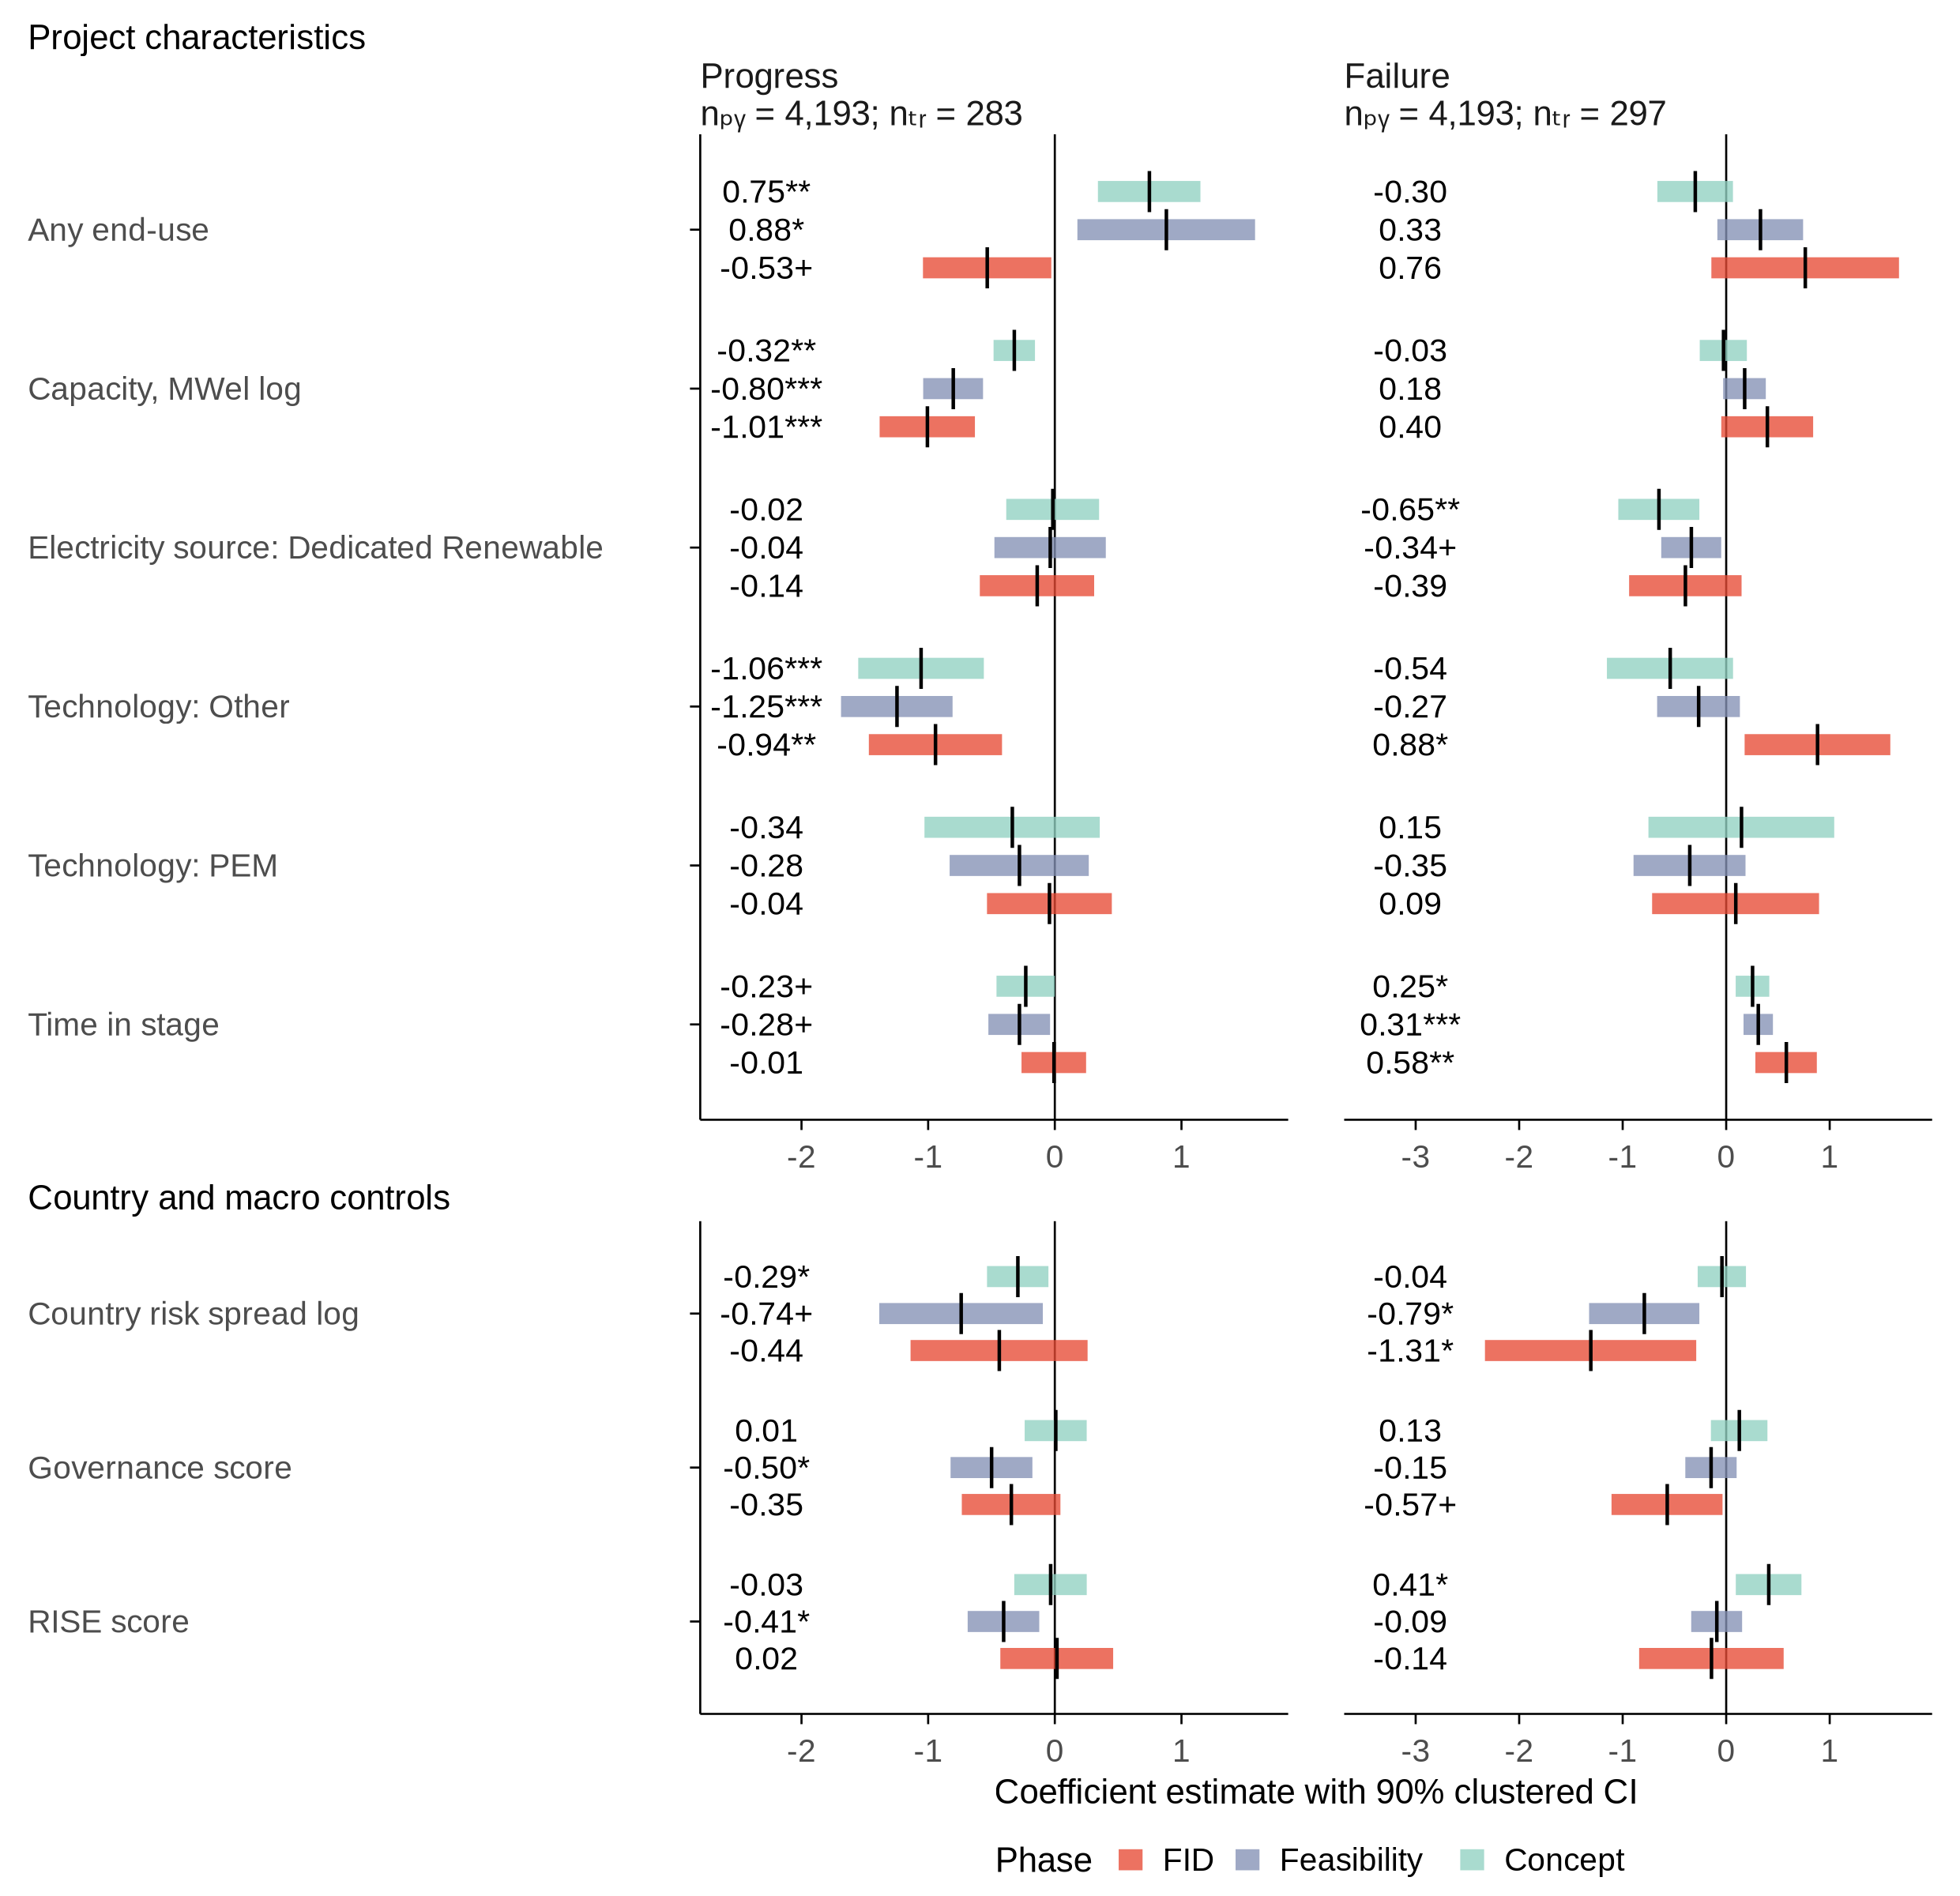

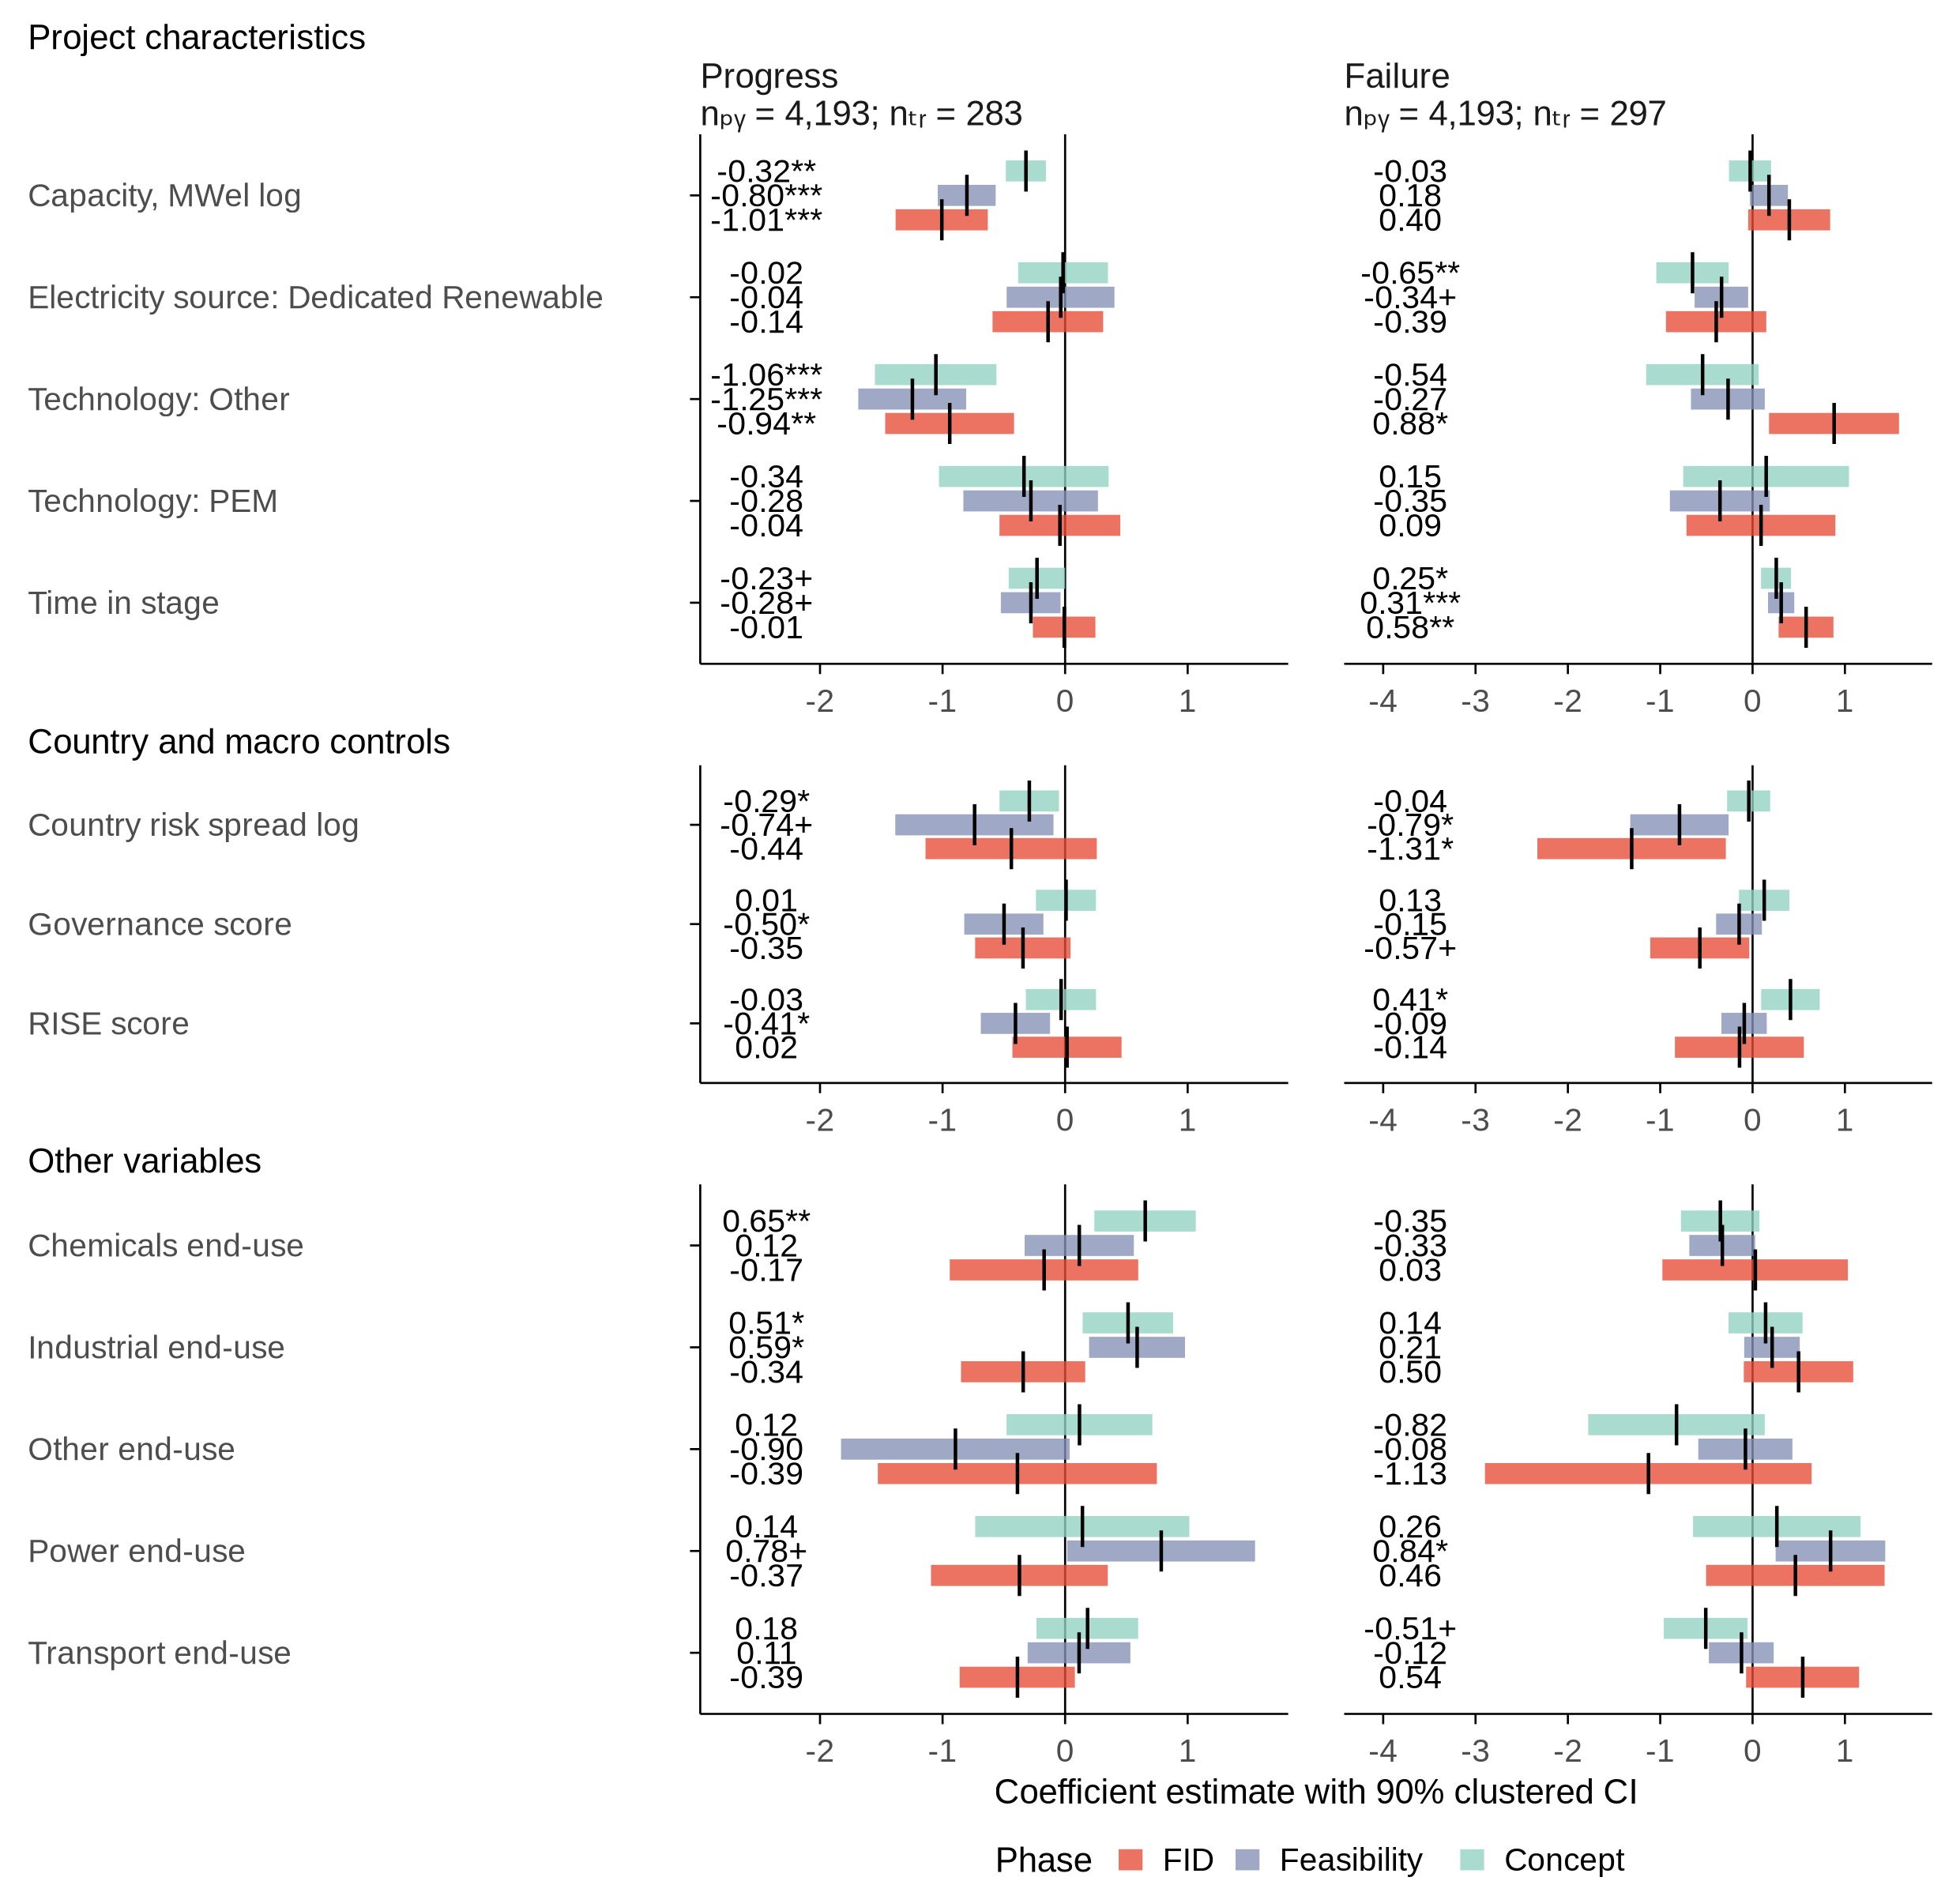

In [18]:
# ==============================================================================
# 16. CREATE, DISPLAY, AND SAVE FIGURE 2
# ==============================================================================

# Main manuscript panel: Any end-use from the any-end-use specification; all
# other displayed coefficients from the grouped end-use specification.
p_tornado_panel <- make_tornado_figure(
  tornado_data_main
)

# Full grouped-end-use panel: all coefficients, including the grouped end-use
# coefficients, come from the grouped end-use specification.
p_tornado_panel_full <- make_tornado_figure(
  tornado_data_full
)

options(
  repr.plot.width = 8.27,
  repr.plot.height = 8,
  repr.plot.res = 300
)

p_tornado_panel
p_tornado_panel_full


ggsave(
  filename = "figure_tornado.pdf",
  plot = p_tornado_panel,
  width = 8.27,
  height = 10.5,
  units = "in",
  device = cairo_pdf
)

ggsave(
  filename = "figure_tornado_full.pdf",
  plot = p_tornado_panel_full,
  width = 8.27,
  height = 10.5,
  units = "in",
  device = cairo_pdf
)


## Supplementary Figure S2: Variable distribution

This supplementary figure summarizes the distributions of the covariates displayed across the two tornado specifications. Numeric variables are shown as histograms; categorical and binary variables are shown as count bars. The figure uses unique pre-operational project-year observations and excludes region because region coefficients are intentionally omitted from the tornado charts.


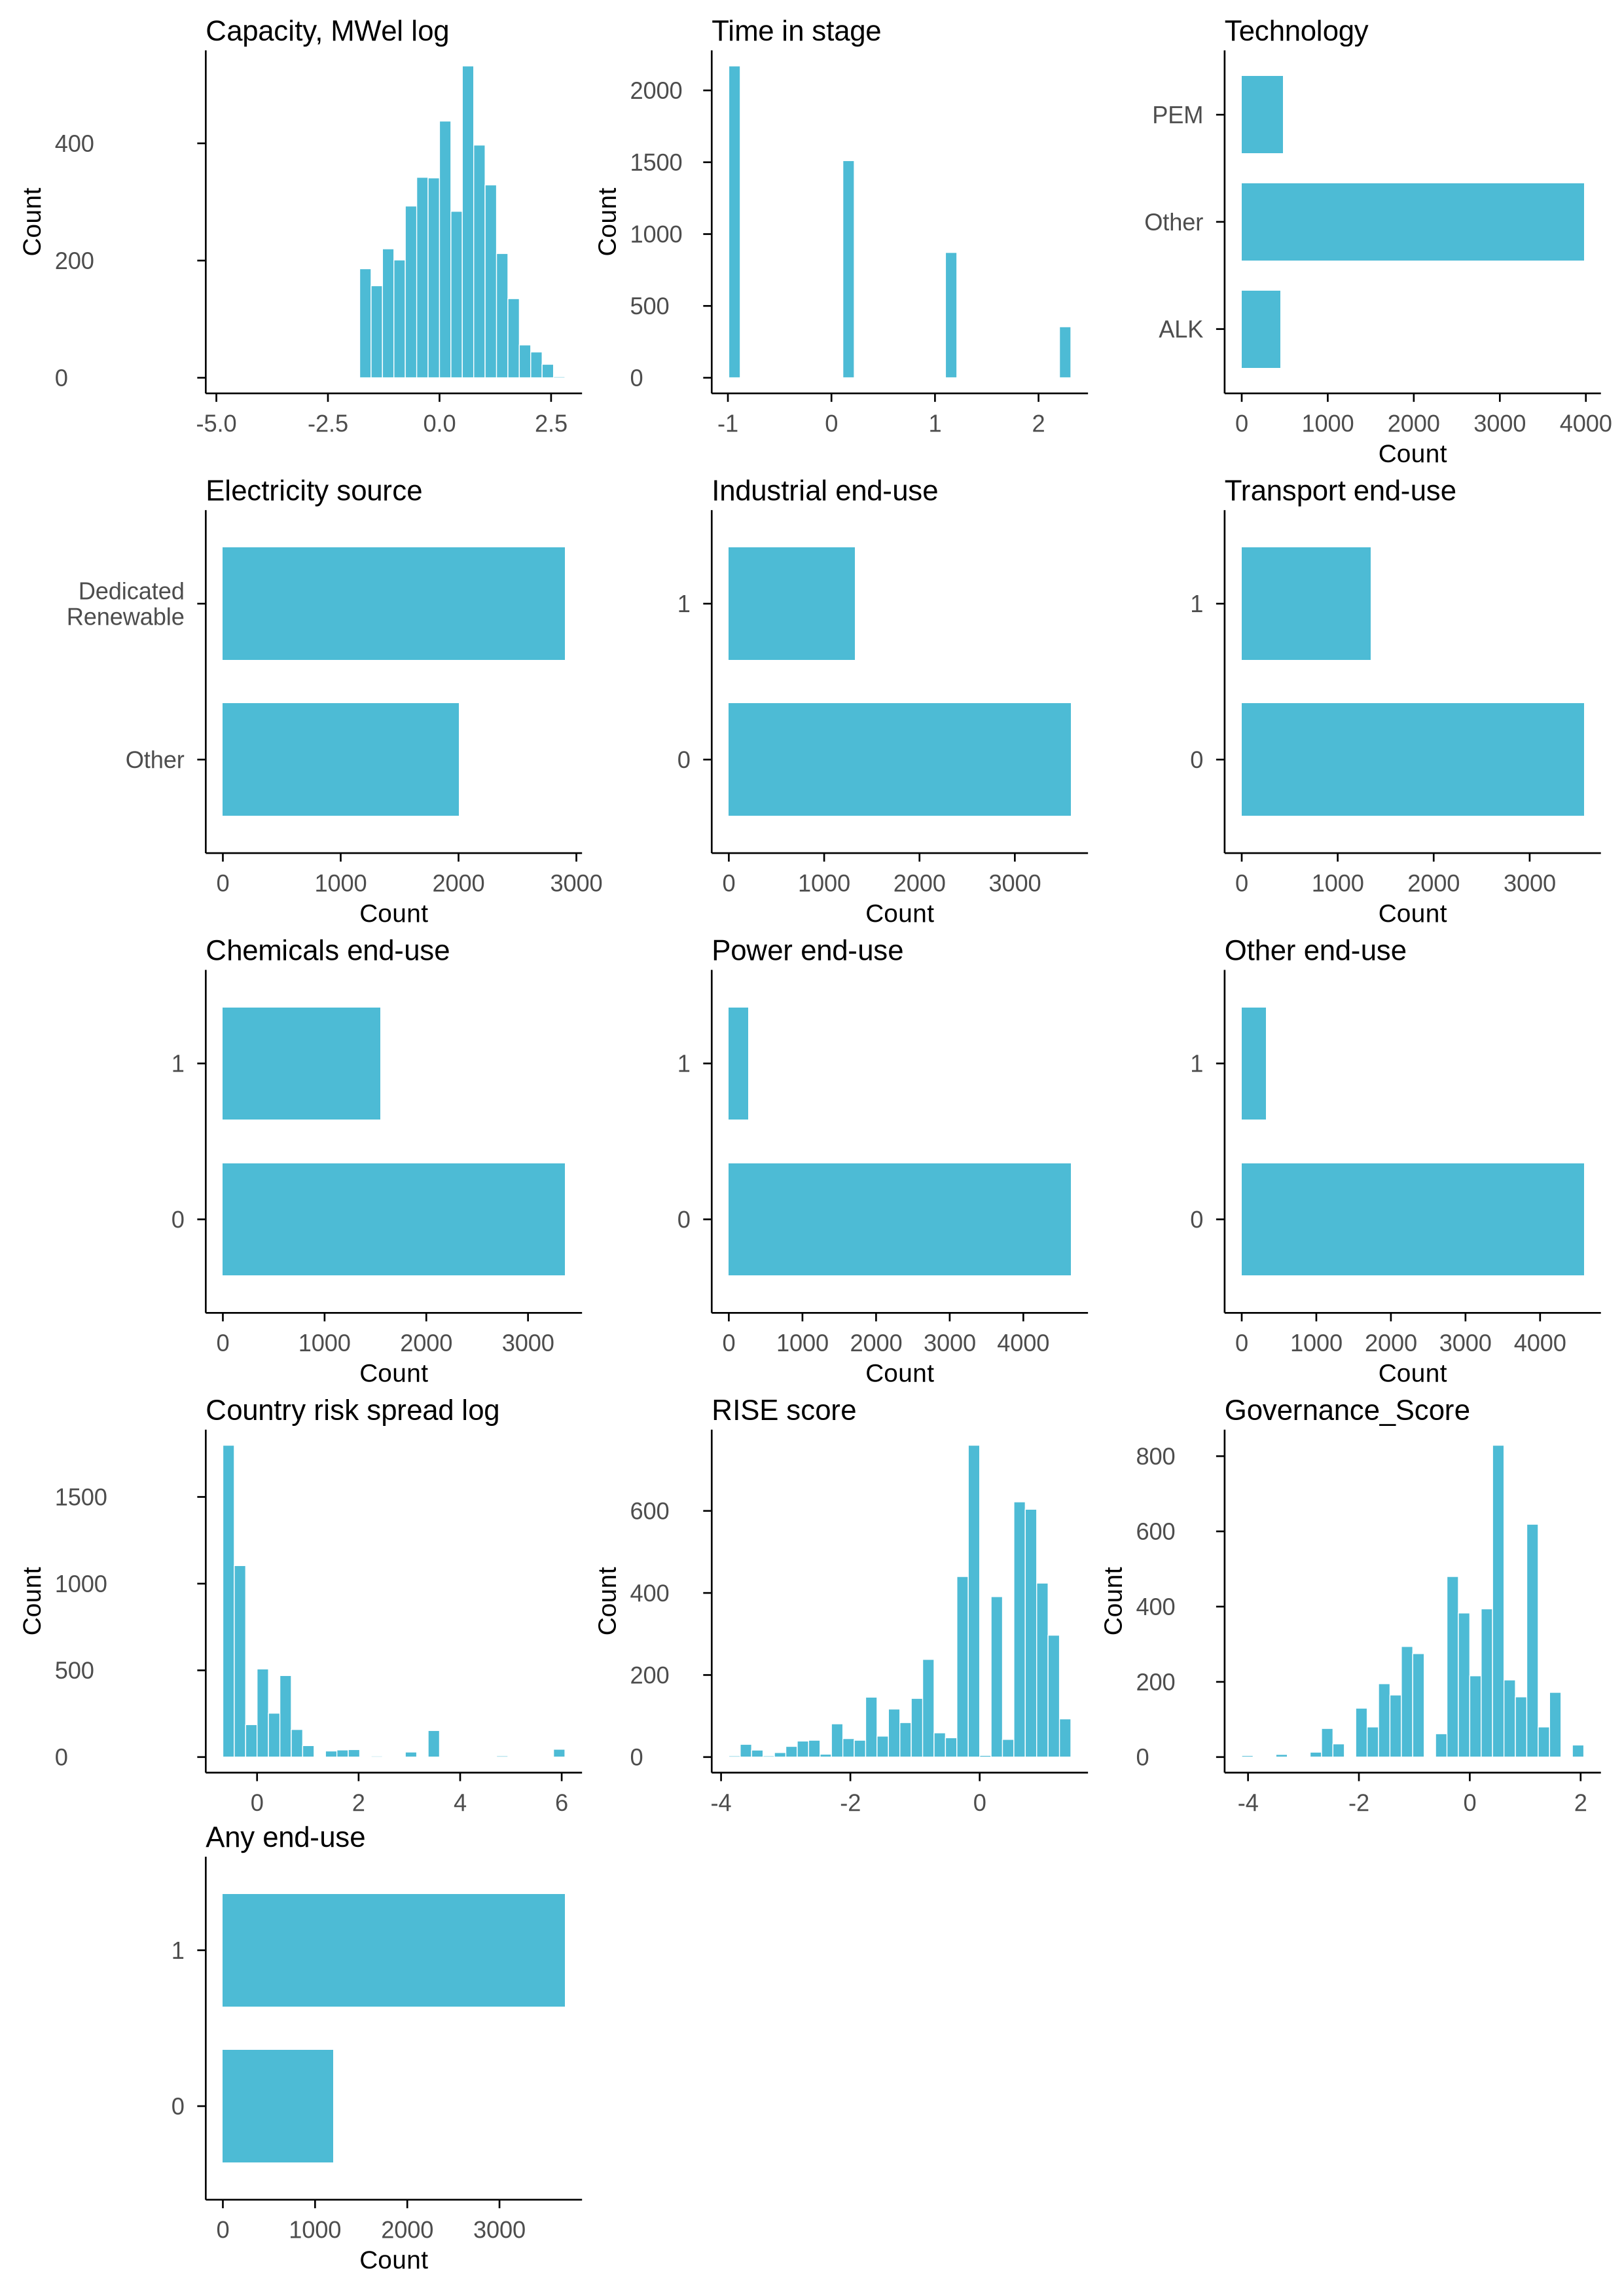

In [19]:
# ==============================================================================
# 17. SUPPLEMENTARY FIGURE: DISTRIBUTIONS OF TORNADO VARIABLES
# ==============================================================================
#
# The figure covers the union of covariates displayed across the specific
# end-use and any-end-use tornado specifications. Region is a model control but
# is intentionally omitted because its treatment-coded coefficients are not
# displayed in either tornado chart.


# ------------------------------------------------------------------------------
# Variables and labels
# ------------------------------------------------------------------------------

distribution_variables <- unique(
  c(
    core_controls,
    enduse_controls_grouped,
    macro_controls,
    "any_enduse"
  )
)

distribution_variables <- setdiff(
  distribution_variables,
  c(
    "region"
  )
)

distribution_variables <- distribution_variables[
  distribution_variables %in% names(cloglog_data)
]

distribution_labels <- c(
  cap.mwel_log = "Capacity, MWel log",
  prev_time_in_status = "Time in stage",
  technology = "Technology",
  project_kde_50km = "Project density, 50 km",
  electricity_source = "Electricity source",
  any_enduse = "Any end-use",
  enduse_industrial = "Industrial end-use",
  enduse_transport = "Transport end-use",
  enduse_chemicals = "Chemicals end-use",
  enduse_power = "Power end-use",
  enduse_other = "Other end-use",
  Country_Risk_Spread_log = "Country risk spread log",
  RISE = "RISE score"
)


# ------------------------------------------------------------------------------
# Use each pre-operational project-year only once
# ------------------------------------------------------------------------------

distribution_data <- cloglog_data %>%
  dplyr::filter(
    prev_state %in% c(
      1,
      2,
      3
    )
  ) %>%
  dplyr::select(
    reference,
    year,
    dplyr::all_of(
      distribution_variables
    )
  ) %>%
  dplyr::distinct(
    reference,
    year,
    .keep_all = TRUE
  )


# ------------------------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------------------------

wrap_distribution_label <- function(x) {
  vapply(
    x,
    function(label) {
      paste(
        strwrap(
          label,
          width = 18
        ),
        collapse = "\n"
      )
    },
    character(1)
  )
}

is_categorical_distribution <- function(x) {
  if (
    is.factor(x) ||
      is.character(x) ||
      is.logical(x)
  ) {
    return(TRUE)
  }

  x_nonmissing <- x[
    !is.na(x)
  ]

  if (
    is.numeric(x_nonmissing) &&
      length(x_nonmissing) > 0 &&
      dplyr::n_distinct(x_nonmissing) <= 8 &&
      all(
        abs(
          x_nonmissing - round(
            x_nonmissing
          )
        ) < 1e-10
      )
  ) {
    return(TRUE)
  }

  FALSE
}

make_distribution_panel <- function(variable_name) {
  variable_label <- if (
    variable_name %in% names(distribution_labels)
  ) {
    unname(
      distribution_labels[
        variable_name
      ]
    )
  } else {
    variable_name
  }

  variable_values <- distribution_data[[variable_name]]

  panel_data <- tibble::tibble(
    value = variable_values
  ) %>%
    dplyr::filter(
      !is.na(value)
    )

  if (nrow(panel_data) == 0) {
    return(
      ggplot() +
        annotate(
          "text",
          x = 0,
          y = 0,
          label = "No non-missing observations",
          size = 3.45
        ) +
        labs(
          title = variable_label
        ) +
        theme_void(
          base_size = 10.5
        ) +
        theme(
          plot.title = element_text(
            size = 10.5,
            face = "plain",
            hjust = 0
          )
        )
    )
  }

  if (
    is_categorical_distribution(
      variable_values
    )
  ) {
    panel_data <- panel_data %>%
      dplyr::mutate(
        value = as.factor(
          value
        )
      )

    ggplot(
      panel_data,
      aes(
        x = value
      )
    ) +
      geom_bar(
        width = 0.72,
        fill = ggsci::pal_npg(
          palette = "nrc",
          alpha = 1
        )(10)[2]
      ) +
      coord_flip() +
      scale_x_discrete(
        labels = wrap_distribution_label
      ) +
      labs(
        title = variable_label,
        x = NULL,
        y = "Count"
      ) +
      base_theme +
      theme(
        legend.position = "none",
        plot.title = element_text(
          size = 10.5,
          face = "plain",
          hjust = 0,
          margin = margin(
            b = 2
          )
        ),
        axis.text.x = element_text(
          size = 8.7
        ),
        axis.text.y = element_text(
          size = 8.7,
          hjust = 1
        ),
        axis.title.y = element_blank(),
        axis.title.x = element_text(
          size = 9.3
        ),
        plot.margin = margin(
          2,
          3,
          2,
          3
        )
      )
  } else {
    ggplot(
      panel_data,
      aes(
        x = value
      )
    ) +
      geom_histogram(
        bins = 30,
        boundary = 0,
        closed = "left",
        fill = ggsci::pal_npg(
          palette = "nrc",
          alpha = 1
        )(10)[2],
        colour = "white",
        linewidth = 0.15
      ) +
      labs(
        title = variable_label,
        x = NULL,
        y = "Count"
      ) +
      base_theme +
      theme(
        legend.position = "none",
        plot.title = element_text(
          size = 10.5,
          face = "plain",
          hjust = 0,
          margin = margin(
            b = 2
          )
        ),
        axis.text.x = element_text(
          size = 8.7
        ),
        axis.text.y = element_text(
          size = 8.7
        ),
        axis.title.y = element_text(
          size = 9.3
        ),
        axis.title.x = element_blank(),
        plot.margin = margin(
          2,
          3,
          2,
          3
        )
      )
  }
}


# ------------------------------------------------------------------------------
# Assemble, display, and export
# ------------------------------------------------------------------------------

distribution_panels <- purrr::map(
  distribution_variables,
  make_distribution_panel
)

p_tornado_distributions <- patchwork::wrap_plots(
  distribution_panels,
  ncol = 3
)

options(
  repr.plot.width = 8.27,
  repr.plot.height = 11.69,
  repr.plot.res = 300
)

p_tornado_distributions

ggsave(
  filename = "figure_S2_variable_distribution.pdf",
  plot = p_tornado_distributions,
  width = 8.27,
  height = 15.5,
  units = "in",
  device = cairo_pdf
)


In [20]:
# ------------------------------------------------------------------------------
# Technology breakdown
# ------------------------------------------------------------------------------

technology_breakdown <- distribution_data %>%
  dplyr::filter(
    !is.na(technology)
  ) %>%
  dplyr::count(
    technology,
    name = "n_project_years"
  ) %>%
  dplyr::mutate(
    share = n_project_years / sum(n_project_years),
    share_percent = 100 * share
  ) %>%
  dplyr::arrange(
    dplyr::desc(n_project_years)
  )

print(
  technology_breakdown
)


# A tibble: 3 × 4
  technology n_project_years  share share_percent
  <fct>                <int>  <dbl>         <dbl>
1 Other                 3976 0.810          81.0 
2 PEM                    480 0.0978          9.78
3 ALK                    452 0.0921          9.21


In [21]:
# ==============================================================================
# 18. PRINT AND EXPORT MODEL DIAGNOSTICS
# ==============================================================================
#
# Diagnostics are printed last so every issue is explicitly linked to its
# transition and model specification.

cat(
  "\nModel diagnostics by transition and specification\n"
)

if (nrow(model_diagnostics) == 0) {
  cat(
    "No convergence or clustered-inference issues were detected.\n"
  )
} else {
  print(
    model_diagnostics,
    n = Inf,
    width = Inf
  )
}

utils::write.csv(
  model_diagnostics,
  "model_diagnostics.csv",
  row.names = FALSE
)



Model diagnostics by transition and specification
No convergence or clustered-inference issues were detected.
